# Credit Card Customer Churn Prediction

**Goal:** Build a classifier that flags customers likely to close their credit card account, giving the bank a window to intervene before it happens.

**Dataset:** [Credit Card Customers (Kaggle)](https://www.kaggle.com/datasets/sakshigoyal7/credit-card-customers) - 10,127 customers, 21 features covering demographics, card info, and transaction behaviour.

### Outline

| # | Section | What we do |
|---|---------|------------|
| 1 | Setup & Data Ingestion | Environment, libraries, load CSV, quality check |
| 2 | Exploratory Data Analysis | Distributions, churn rates by segment, correlations |
| 3 | Customer Segmentation | K-Means clustering, churn rates per segment, cluster profiling |
| 4 | Dimensionality Reduction | PCA + t-SNE 2D projections to visualize churn separation |
| 5 | Feature Engineering & Preprocessing | Encoding, train/test split, pipeline with SMOTE |
| 6 | Model Training & Selection | 5-fold CV across five classifiers |
| 7 | Evaluation & Interpretation | Test metrics, confusion matrices, ROC/PR, feature importance |
| 8 | Threshold Tuning & Retention Strategy | Optimal cutoff, impact comparison, targeting |
| 9 | Model Export | Save the best pipeline to disk |
| 10 | Conclusion | Takeaways and production considerations |


## 1. Setup & Data Ingestion

We start by importing everything we need. The stack is sklearn + imblearn for the pipeline, XGBoost and LightGBM for boosted trees, and matplotlib/seaborn for plots that render natively on GitHub.


In [43]:
import os
import numpy as np
import pandas as pd
import warnings, joblib

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate,
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
)
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score, silhouette_score,
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

SEED = 42
np.random.seed(SEED)
warnings.filterwarnings("ignore", category=UserWarning)

sns.set_theme(style="whitegrid", context="notebook", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.figsize": (12, 6), "figure.dpi": 120,
    "axes.titleweight": "bold", "axes.titlesize": 13,
})

STATUS_COLORS = {"Existing": "#4C72B0", "Attrited": "#DD8452"}
CLUSTER_CMAP = plt.cm.get_cmap("tab10")



C:\Users\noher\AppData\Local\Temp\ipykernel_1352\202251970.py:47: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  CLUSTER_CMAP = plt.cm.get_cmap("tab10")


### 1.1 Load & First Look

The CSV ships with 23 columns. The last two are pre-computed Naive Bayes outputs the dataset author left in. We drop them right away because they leak the target and would make any model score artificially well.


In [44]:
DATA_PATH = "BankChurners.csv"
raw = pd.read_csv(DATA_PATH)
# Last two columns are leaky Naive Bayes outputs. Drop them.
raw = raw.iloc[:, :-2]
print(f"Shape: {raw.shape[0]:,} rows x {raw.shape[1]} columns")
raw.head()


Shape: 10,127 rows x 21 columns


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [45]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_

In [46]:
raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CLIENTNUM,10127.0,NaN,NaN,NaN,739177606.333663,36903783.450231,708082083.0,713036770.5,717926358.0,773143533.0,828343083.0
Attrition_Flag,10127,2,Existing Customer,8500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_Age,10127.0,NaN,NaN,NaN,46.32596,8.016814,26.0,41.0,46.0,52.0,73.0
Gender,10127,2,F,5358,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependent_count,10127.0,NaN,NaN,NaN,2.346203,1.298908,0.0,1.0,2.0,3.0,5.0
Education_Level,10127,7,Graduate,3128,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Marital_Status,10127,4,Married,4687,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Income_Category,10127,6,Less than $40K,3561,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Card_Category,10127,4,Blue,9436,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Months_on_book,10127.0,NaN,NaN,NaN,35.928409,7.986416,13.0,31.0,36.0,40.0,56.0


### 1.2 Data Quality Check

In [47]:
quality = pd.DataFrame({
    "dtype": raw.dtypes, "n_unique": raw.nunique(),
    "n_missing": raw.isna().sum(),
    "pct_missing": (raw.isna().mean() * 100).round(2),
    "sample_value": raw.iloc[0],
})
quality.style.background_gradient(subset=["pct_missing"], cmap="YlOrRd", vmin=0, vmax=10)


,dtype,n_unique,n_missing,pct_missing,sample_value
CLIENTNUM,int64,10127,0,0.000000,768805383
Attrition_Flag,object,2,0,0.000000,Existing Customer
Customer_Age,int64,45,0,0.000000,45
Gender,object,2,0,0.000000,M
Dependent_count,int64,6,0,0.000000,3
Education_Level,object,7,0,0.000000,High School
Marital_Status,object,4,0,0.000000,Married
Income_Category,object,6,0,0.000000,$60K - $80K
Card_Category,object,4,0,0.000000,Blue
Months_on_book,int64,44,0,0.000000,39


> No missing values in the traditional sense, but `Unknown` appears as a category in Education, Marital Status, and Income. We'll treat it as its own level rather than imputing. `CLIENTNUM` is just a row identifier, so it gets dropped before we model anything.


## 2. Exploratory Data Analysis

Before building models we need to understand what we're working with. This section walks through the target, demographic breakdowns, financial features, and correlations to figure out where the signal actually lives.


In [48]:
# Compute once, reuse everywhere
status = raw['Attrition_Flag'].str.replace(' Customer', '')

### 2.1 Target Distribution

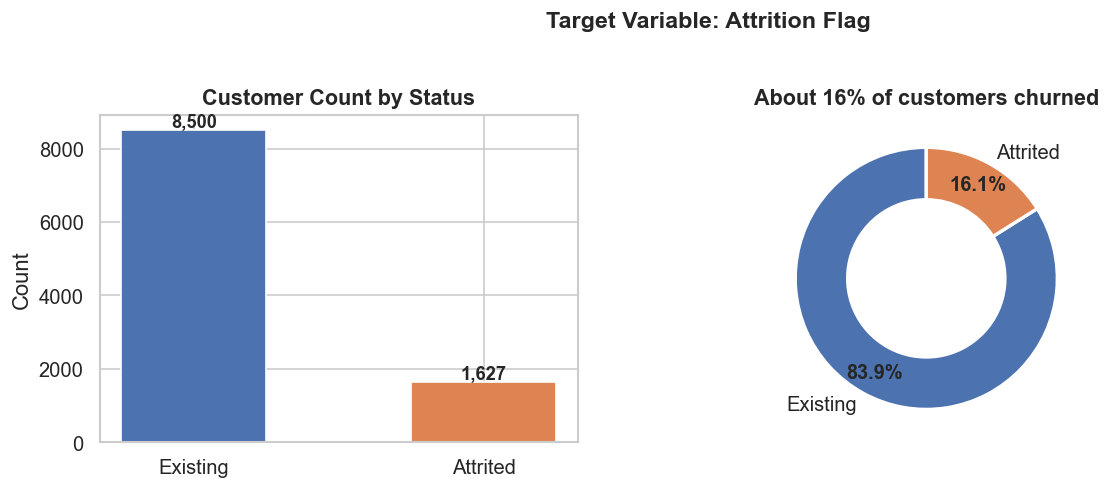

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"width_ratios": [1, 2]})
target_counts = status.value_counts()

ax = axes[0]
bars = ax.bar(target_counts.index, target_counts.values,
    color=[STATUS_COLORS["Existing"], STATUS_COLORS["Attrited"]],
    edgecolor="white", width=0.5)
for bar, val in zip(bars, target_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+80,
            f"{val:,}", ha="center", fontweight="bold", fontsize=11)
ax.set_ylabel("Count"); ax.set_title("Customer Count by Status")

ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    target_counts.values, labels=target_counts.index,
    autopct="%1.1f%%", startangle=90,
    colors=[STATUS_COLORS["Existing"], STATUS_COLORS["Attrited"]],
    pctdistance=0.82, wedgeprops=dict(width=0.4, edgecolor="white", linewidth=2))
for t in autotexts: t.set_fontsize(12); t.set_fontweight("bold")
ax2.set_title("About 16% of customers churned")

fig.suptitle("Target Variable: Attrition Flag", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()


> We're looking at roughly an 84/16 split. Not extreme, but imbalanced enough that a naive "predict everyone stays" classifier would score 84% accuracy while catching zero churners. SMOTE will handle this during training.


### 2.2 Demographics

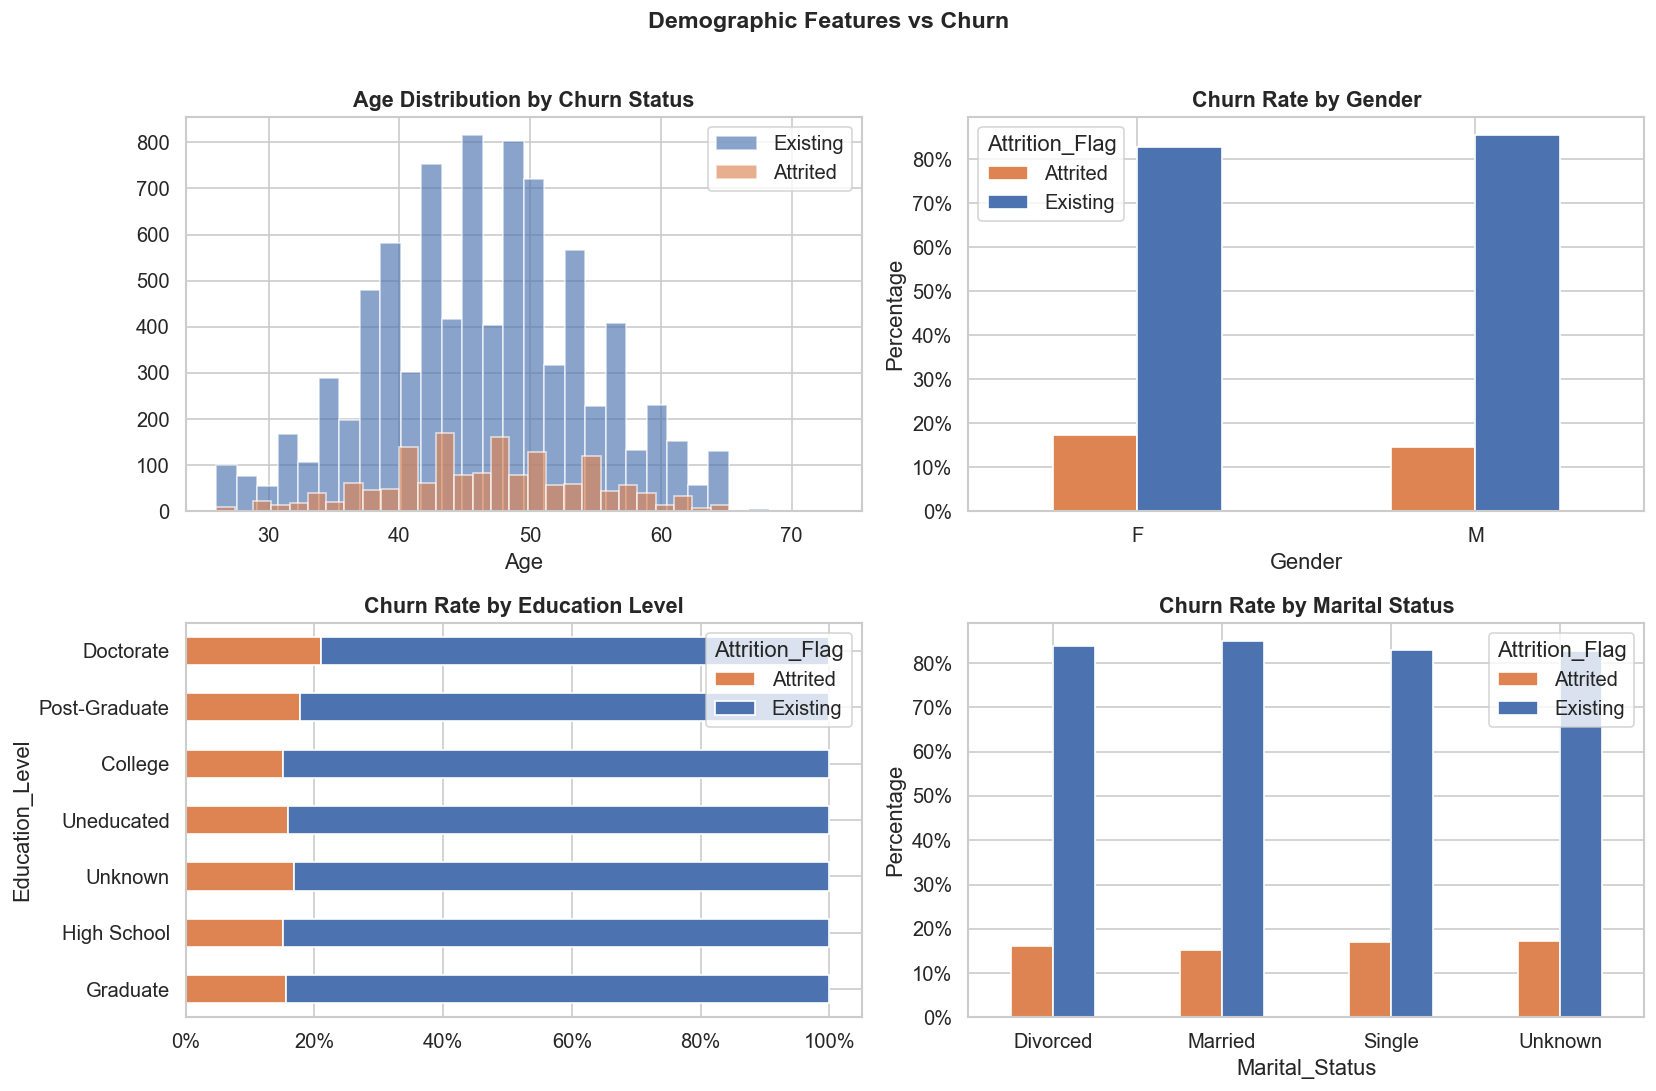

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# pd.crosstab sorts columns alphabetically -> Attrited first, Existing second
ct_colors = [STATUS_COLORS["Attrited"], STATUS_COLORS["Existing"]]

# Age histogram (manual, not crosstab)
ax = axes[0, 0]
for label, color in STATUS_COLORS.items():
    ax.hist(raw.loc[status == label, "Customer_Age"],
            bins=30, alpha=0.65, label=label, color=color, edgecolor="white")
ax.set_xlabel("Age"); ax.set_title("Age Distribution by Churn Status"); ax.legend()

# Gender
ax = axes[0, 1]
ct = pd.crosstab(raw["Gender"], status, normalize="index") * 100
ct.plot.bar(ax=ax, color=ct_colors, edgecolor="white", rot=0)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Churn Rate by Gender"); ax.set_ylabel("Percentage")

# Education
ax = axes[1, 0]
edu_order = raw["Education_Level"].value_counts().index
ct = pd.crosstab(raw["Education_Level"], status, normalize="index").loc[edu_order] * 100
ct.plot.barh(ax=ax, color=ct_colors, edgecolor="white", stacked=True)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Churn Rate by Education Level"); ax.set_xlabel("")

# Marital Status
ax = axes[1, 1]
ct = pd.crosstab(raw["Marital_Status"], status, normalize="index") * 100
ct.plot.bar(ax=ax, color=ct_colors, edgecolor="white", rot=0)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Churn Rate by Marital Status"); ax.set_ylabel("Percentage")

fig.suptitle("Demographic Features vs Churn", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()


### 2.3 Financial & Behavioral Features

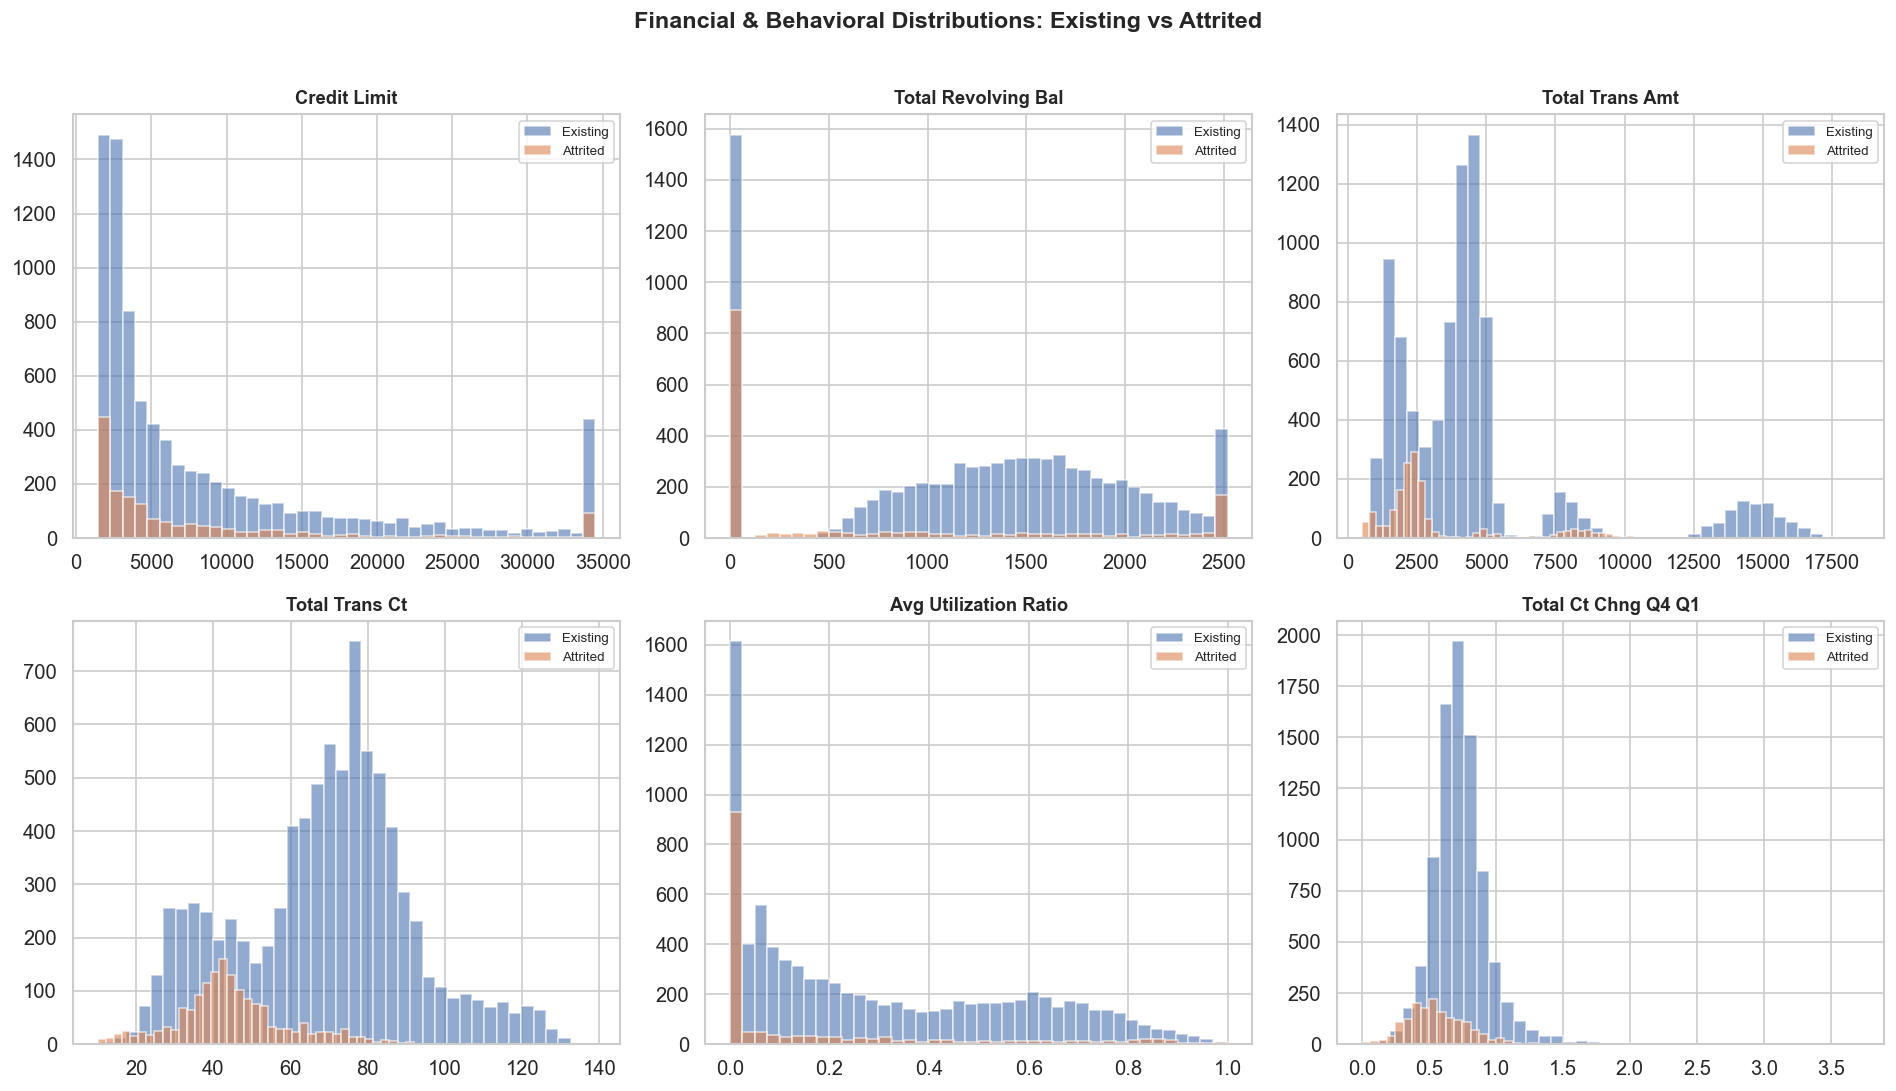

In [51]:
money_cols = ["Credit_Limit", "Total_Revolving_Bal", "Total_Trans_Amt",
              "Total_Trans_Ct", "Avg_Utilization_Ratio", "Total_Ct_Chng_Q4_Q1"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.ravel(), money_cols):
    for label, color in STATUS_COLORS.items():
        ax.hist(raw.loc[status == label, col], bins=40, alpha=0.6,
                label=label, color=color, edgecolor="white")
    ax.set_title(col.replace("_", " "), fontsize=11); ax.legend(fontsize=8)

fig.suptitle("Financial & Behavioral Distributions: Existing vs Attrited",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()


> Now we're getting somewhere. Transaction count and amount show clear separation: churners pile up on the low end. Same with revolving balance and utilization. These people were already disengaging from their card before they officially closed it. The Q4-to-Q1 change in transaction count also skews lower for churners, meaning their activity was trending down.


### 2.4 Card Category & Income Segments

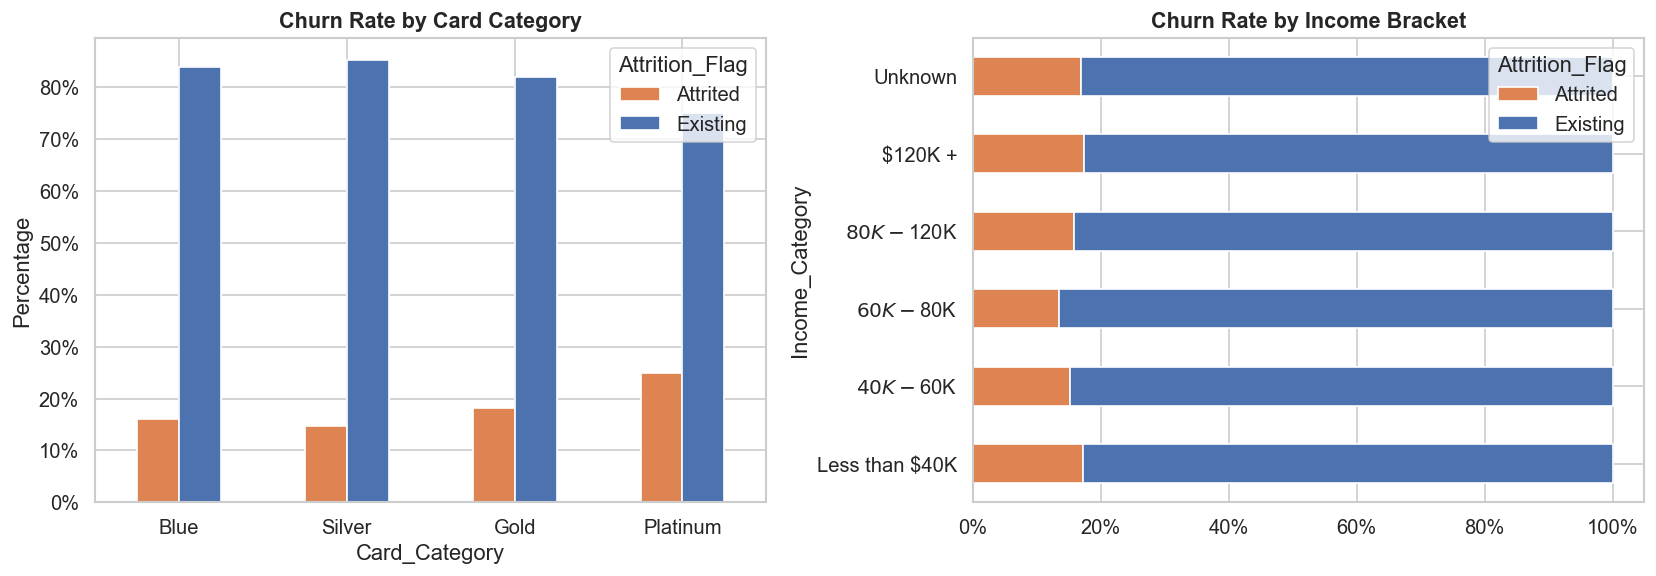

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ct_colors = [STATUS_COLORS["Attrited"], STATUS_COLORS["Existing"]]

ax = axes[0]
card_order = ["Blue", "Silver", "Gold", "Platinum"]
ct = pd.crosstab(raw["Card_Category"], status, normalize="index").reindex(card_order) * 100
ct.plot.bar(ax=ax, color=ct_colors, edgecolor="white", rot=0)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Churn Rate by Card Category"); ax.set_ylabel("Percentage")

ax = axes[1]
income_order = ["Less than $40K", "$40K - $60K", "$60K - $80K",
                "$80K - $120K", "$120K +", "Unknown"]
ct = pd.crosstab(raw["Income_Category"], status, normalize="index").reindex(income_order) * 100
ct.plot.barh(ax=ax, color=ct_colors, edgecolor="white", stacked=True)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Churn Rate by Income Bracket"); ax.set_xlabel("")

plt.tight_layout(); plt.show()


### 2.5 Customer Engagement

C:\Users\noher\AppData\Local\Temp\ipykernel_1352\880236197.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=raw.assign(Status=status), x="Status", y=col, ax=ax,
C:\Users\noher\AppData\Local\Temp\ipykernel_1352\880236197.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=raw.assign(Status=status), x="Status", y=col, ax=ax,
C:\Users\noher\AppData\Local\Temp\ipykernel_1352\880236197.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=raw.assign(Status=status), x="Status", y=col, ax=ax,
C:\Users\noher\AppData\Local\Temp\ipyker

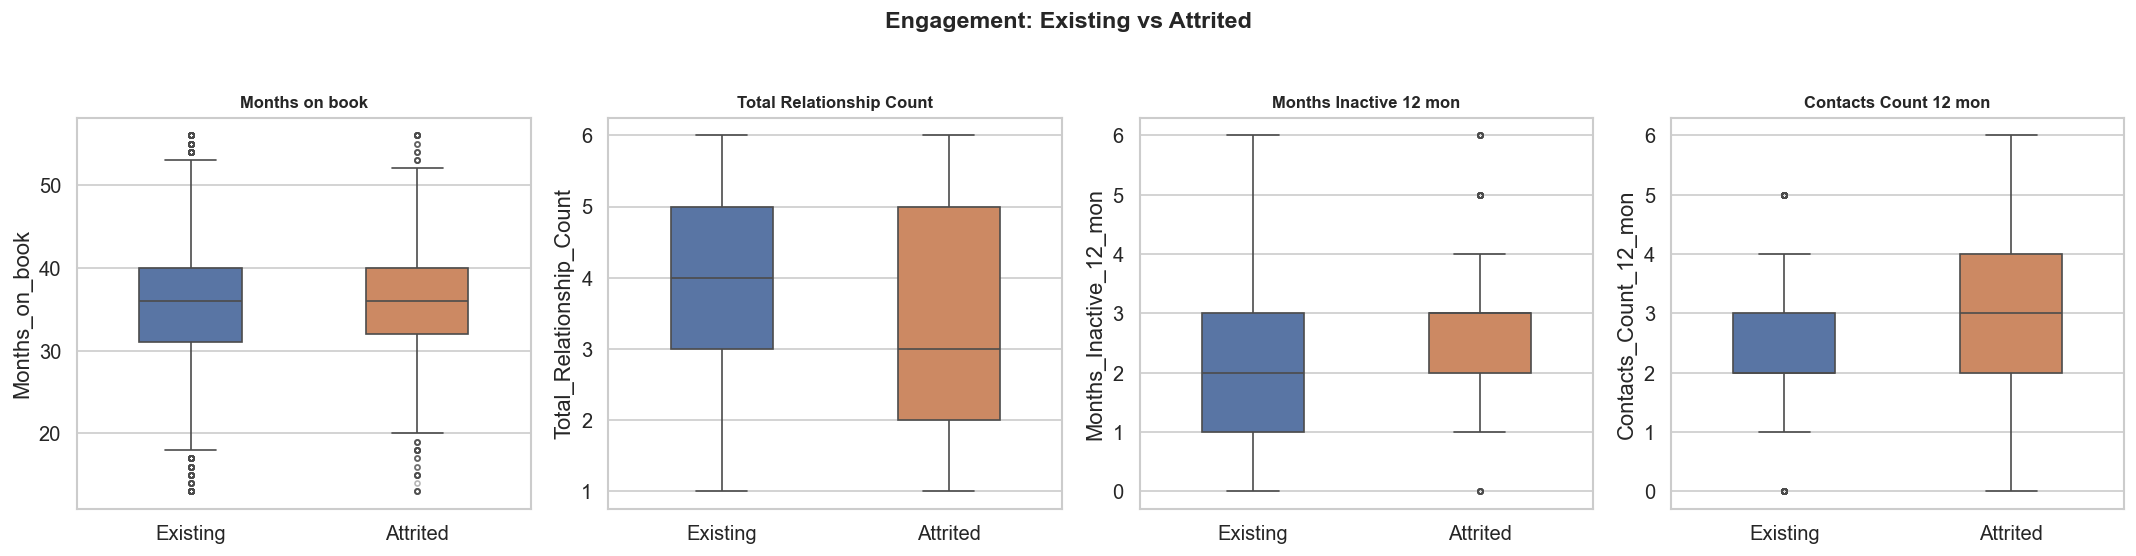

In [53]:
engage_cols = ["Months_on_book", "Total_Relationship_Count",
               "Months_Inactive_12_mon", "Contacts_Count_12_mon"]

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, col in zip(axes, engage_cols):
    sns.boxplot(data=raw.assign(Status=status), x="Status", y=col, ax=ax,
                palette=STATUS_COLORS, width=0.45,
                flierprops=dict(marker="o", markersize=3, alpha=0.4))
    ax.set_title(col.replace("_", " "), fontsize=10); ax.set_xlabel("")

fig.suptitle("Engagement: Existing vs Attrited", fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout(); plt.show()


> More months inactive, more bank contacts (probably complaints or unresolved issues), and fewer products held. The classic disengagement pattern: less invested in the relationship, more frustrated, and eventually gone.


### 2.6 Correlation Matrix

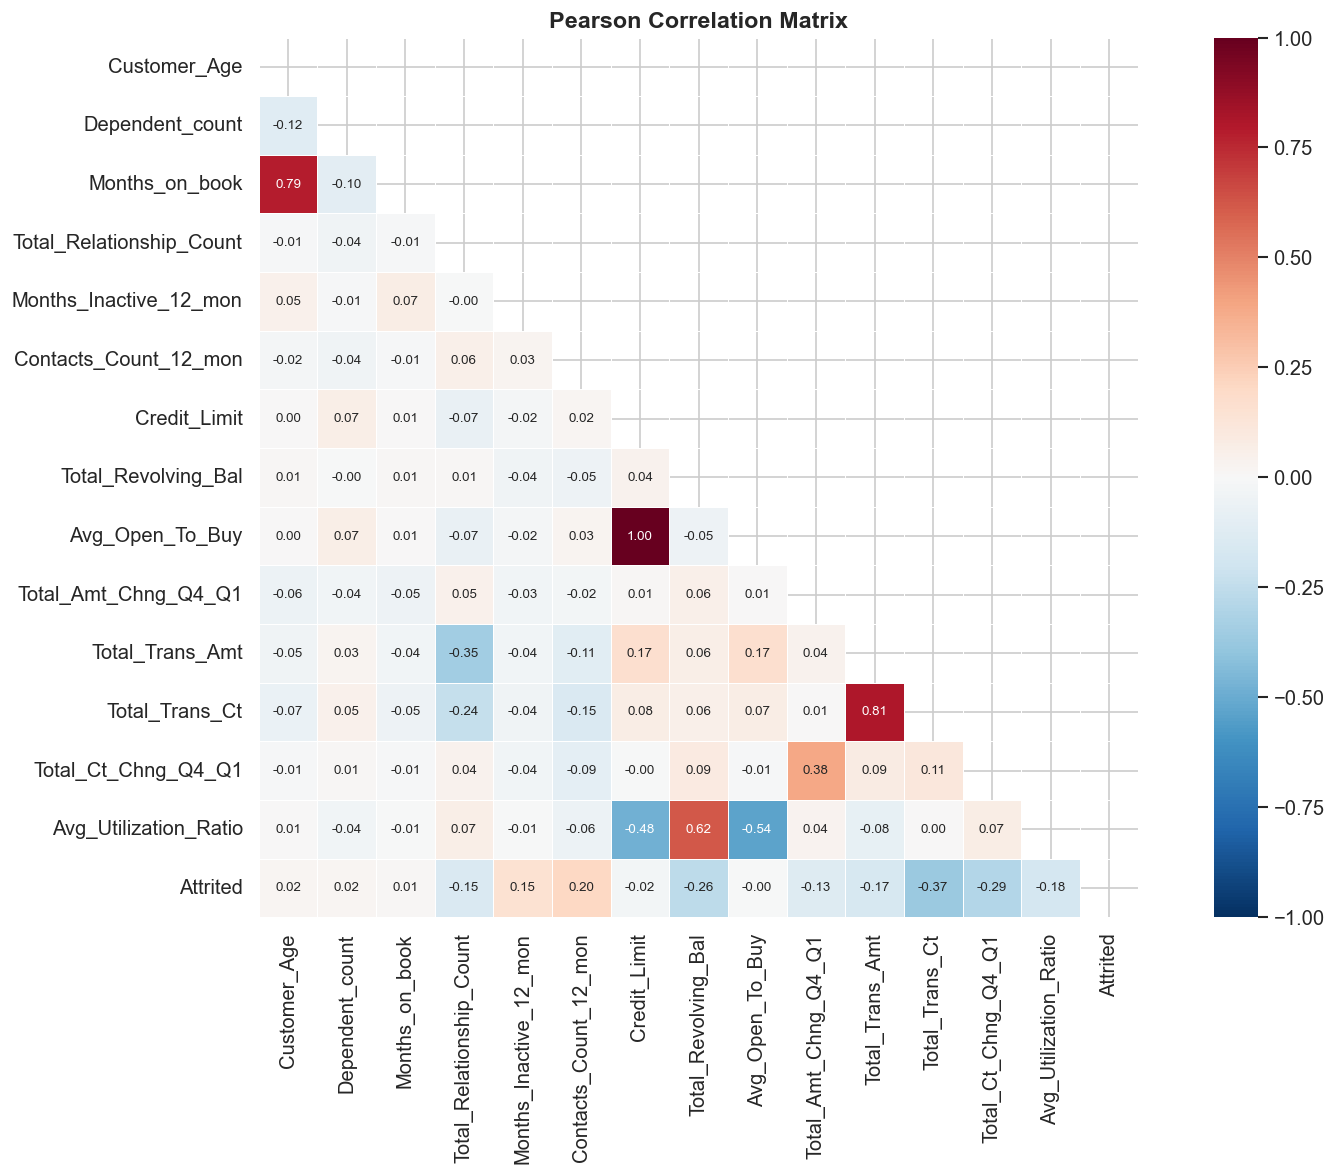

In [54]:
num_df = raw.select_dtypes(include="number").drop(columns=["CLIENTNUM"])
num_df["Attrited"] = (raw["Attrition_Flag"] == "Attrited Customer").astype(int)
corr_matrix = num_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=0.5, square=True, ax=ax, annot_kws={"size": 8})
ax.set_title("Pearson Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()


### 2.7 Feature Correlation with Churn

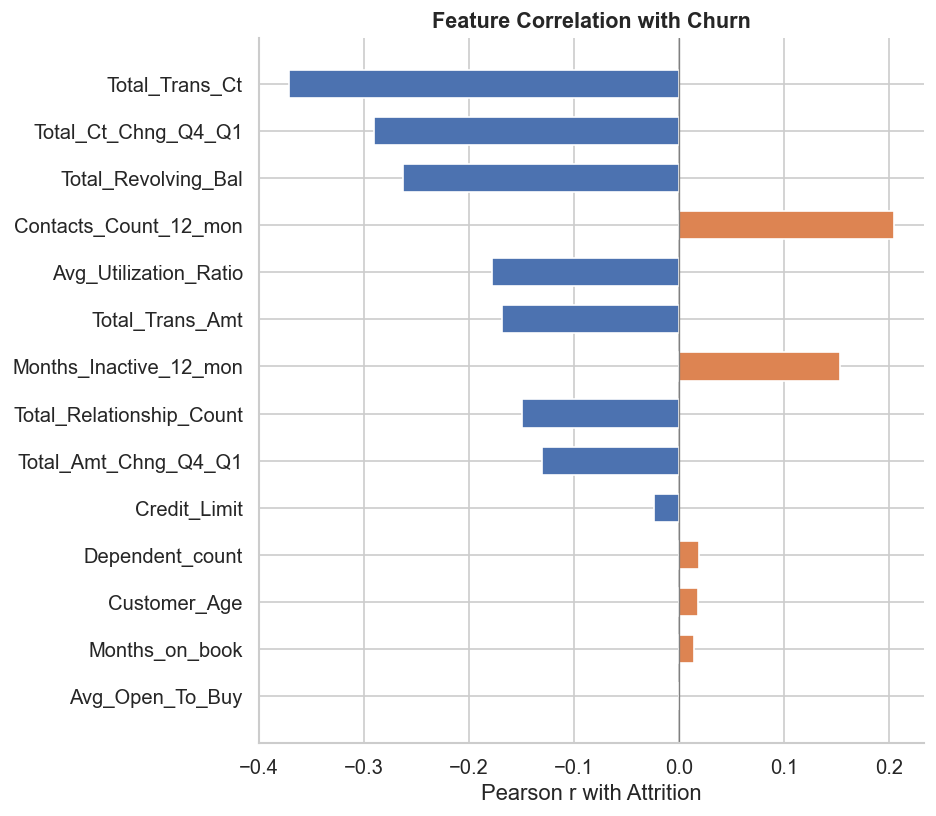

In [55]:
churn_corr = corr_matrix["Attrited"].drop("Attrited").sort_values(key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
bar_colors = ["#DD8452" if v > 0 else "#4C72B0" for v in churn_corr.values]
ax.barh(churn_corr.index, churn_corr.values, color=bar_colors, edgecolor="white", height=0.6)
ax.axvline(0, color="grey", linewidth=0.8)
ax.set_xlabel("Pearson r with Attrition")
ax.set_title("Feature Correlation with Churn", fontweight="bold")
for spine in ["top", "right"]: ax.spines[spine].set_visible(False)
plt.tight_layout(); plt.show()


> The ranking is clear. Transaction count and amount are the top two predictors, followed by the Q4/Q1 change ratio and revolving balance. Everything else (age, tenure, credit limit) barely registers. Good to confirm early on that the answer won't be found in who the customer *is*, but in what they *do*.


### 2.8 Additional Risk Views

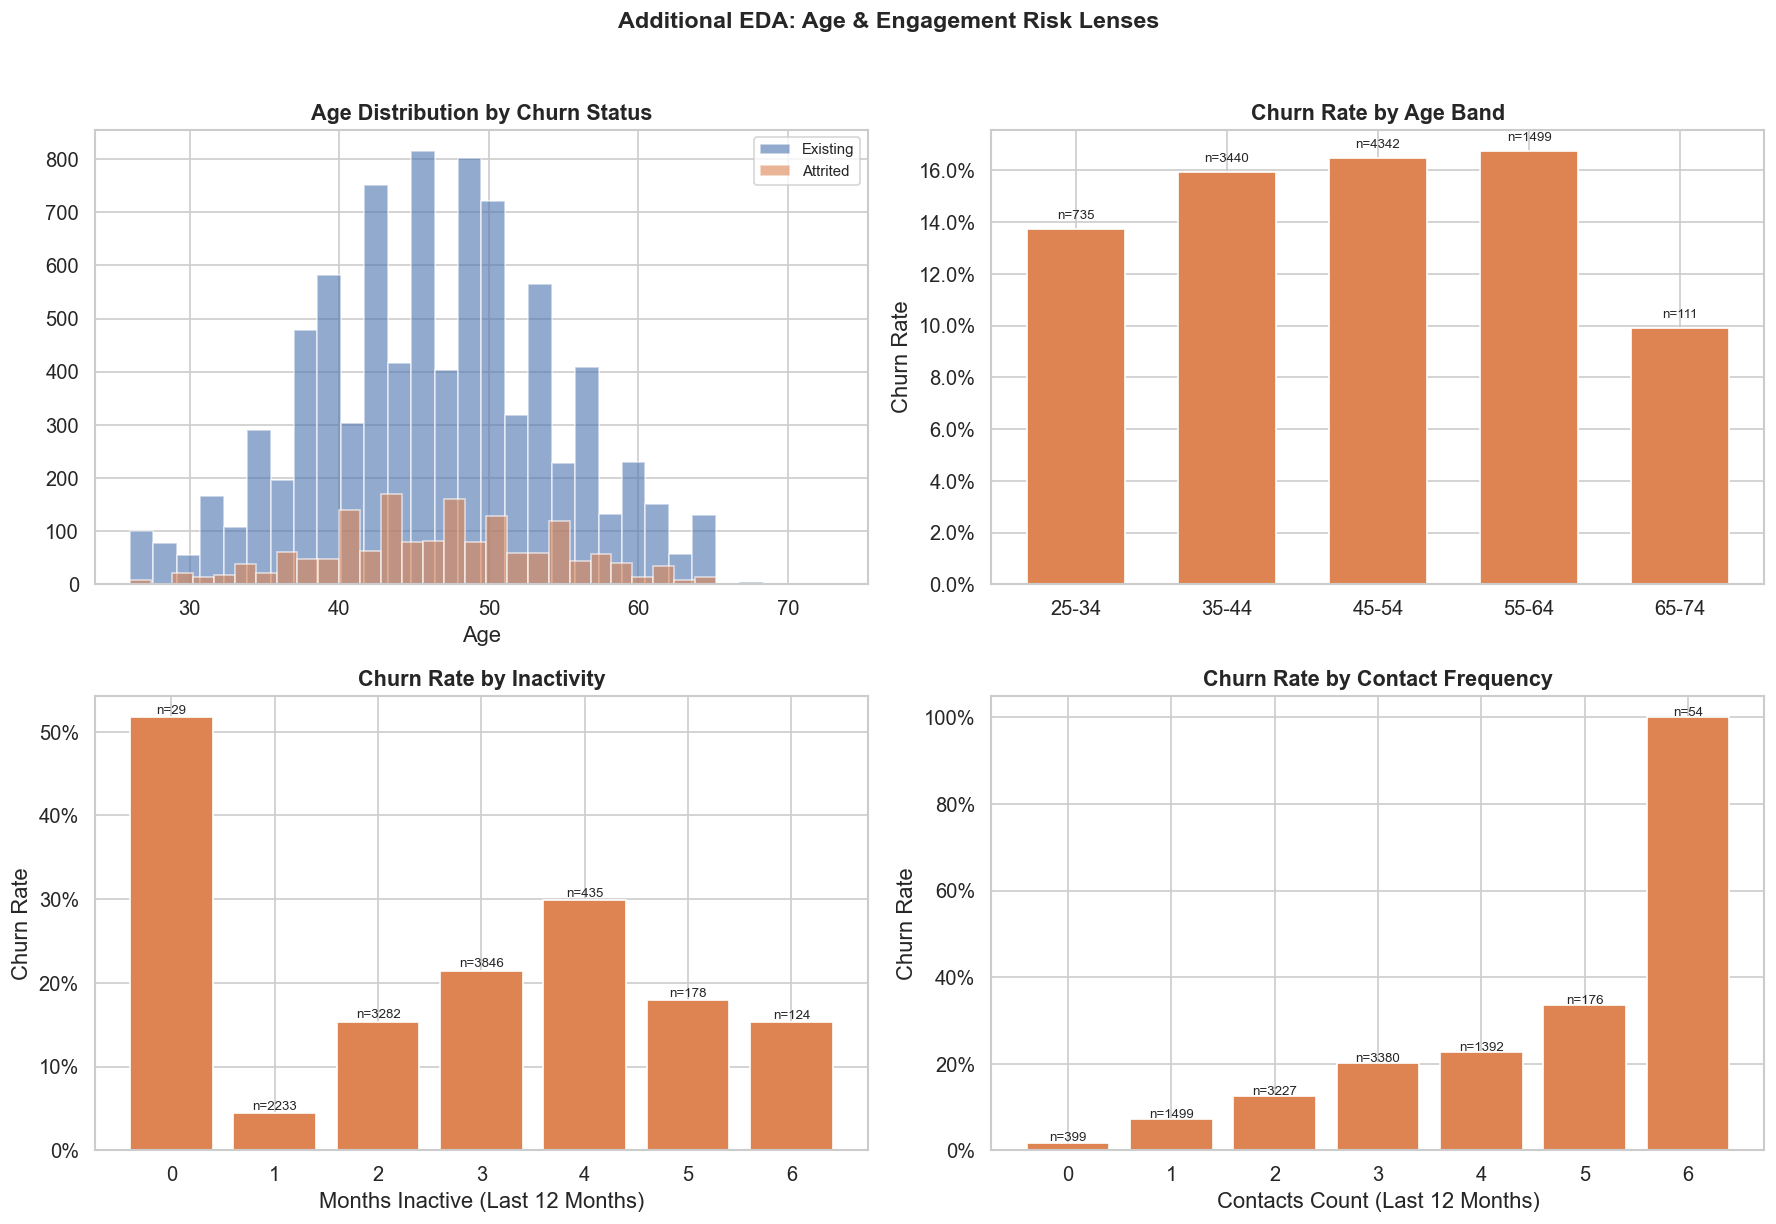

In [56]:
eda = raw.assign(Status=status, Attrited=(status == "Attrited").astype(int)).copy()

age_bins = [25, 35, 45, 55, 65, 75]
age_labels = ["25-34", "35-44", "45-54", "55-64", "65-74"]
eda["Age_Band"] = pd.cut(eda["Customer_Age"], bins=age_bins, labels=age_labels, right=False)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Age distribution overlay
ax = axes[0, 0]
for label, color in STATUS_COLORS.items():
    ax.hist(eda.loc[eda["Status"] == label, "Customer_Age"],
            bins=30, alpha=0.6, label=label, color=color, edgecolor="white")
ax.set_xlabel("Age")
ax.set_title("Age Distribution by Churn Status")
ax.legend(fontsize=9)

# Churn rate by age band
ax = axes[0, 1]
age_rate = eda.groupby("Age_Band", observed=False)["Attrited"].mean().mul(100)
age_count = eda.groupby("Age_Band", observed=False)["Attrited"].size()
bars = ax.bar(age_rate.index.astype(str), age_rate.values, color="#DD8452", edgecolor="white", width=0.65)
for bar, cnt in zip(bars, age_count.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f"n={cnt}", ha="center", fontsize=8)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylabel("Churn Rate")
ax.set_title("Churn Rate by Age Band")

# Churn rate by inactivity
ax = axes[1, 0]
inactive_rate = eda.groupby("Months_Inactive_12_mon")["Attrited"].mean().mul(100).sort_index()
inactive_count = eda.groupby("Months_Inactive_12_mon")["Attrited"].size().sort_index()
bars = ax.bar(inactive_rate.index.astype(str), inactive_rate.values, color="#DD8452", edgecolor="white")
for bar, cnt in zip(bars, inactive_count.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f"n={cnt}", ha="center", fontsize=8)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel("Months Inactive (Last 12 Months)")
ax.set_ylabel("Churn Rate")
ax.set_title("Churn Rate by Inactivity")

# Churn rate by contacts
ax = axes[1, 1]
contact_rate = eda.groupby("Contacts_Count_12_mon")["Attrited"].mean().mul(100).sort_index()
contact_count = eda.groupby("Contacts_Count_12_mon")["Attrited"].size().sort_index()
bars = ax.bar(contact_rate.index.astype(str), contact_rate.values, color="#DD8452", edgecolor="white")
for bar, cnt in zip(bars, contact_count.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f"n={cnt}", ha="center", fontsize=8)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel("Contacts Count (Last 12 Months)")
ax.set_ylabel("Churn Rate")
ax.set_title("Churn Rate by Contact Frequency")

fig.suptitle("Additional EDA: Age & Engagement Risk Lenses",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()


> Age risk is not strictly linear across bands. The more actionable pattern is in operational behaviour: churn jumps sharply with inactivity and repeated customer contacts. Both make solid early-warning signals for a monitoring system.


### 2.9 Demographic Base Profile

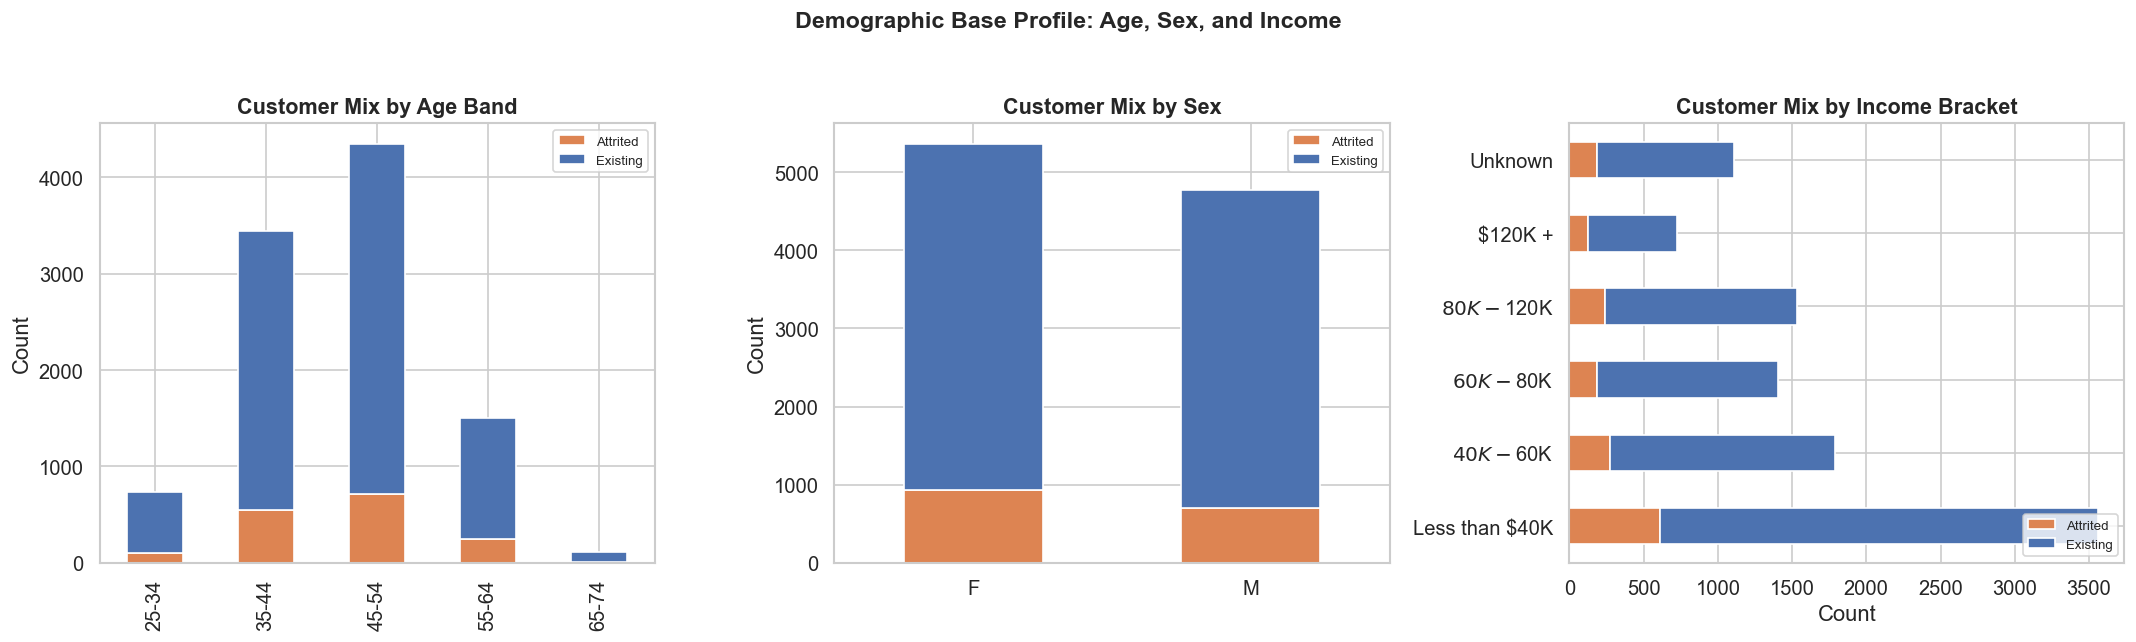

In [57]:
demo = raw.assign(Status=status).copy()

age_bins = [25, 35, 45, 55, 65, 75]
age_labels = ["25-34", "35-44", "45-54", "55-64", "65-74"]
demo["Age_Band"] = pd.cut(demo["Customer_Age"], bins=age_bins, labels=age_labels, right=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.2))
ct_colors = [STATUS_COLORS["Attrited"], STATUS_COLORS["Existing"]]

# Age base distribution
ax = axes[0]
age_mix = pd.crosstab(demo["Age_Band"], demo["Status"]).reindex(age_labels)
age_mix = age_mix.reindex(columns=["Attrited", "Existing"]).fillna(0)
age_mix.plot.bar(ax=ax, color=ct_colors, edgecolor="white", stacked=True)
ax.set_title("Customer Mix by Age Band")
ax.set_xlabel("")
ax.set_ylabel("Count")
ax.legend(title="", fontsize=8)

# Sex base distribution
ax = axes[1]
sex_mix = pd.crosstab(demo["Gender"], demo["Status"])
sex_mix = sex_mix.reindex(columns=["Attrited", "Existing"]).fillna(0)
sex_mix.plot.bar(ax=ax, color=ct_colors, edgecolor="white", stacked=True, rot=0)
ax.set_title("Customer Mix by Sex")
ax.set_xlabel("")
ax.set_ylabel("Count")
ax.legend(title="", fontsize=8)

# Income base distribution
ax = axes[2]
income_order = ["Less than $40K", "$40K - $60K", "$60K - $80K",
                "$80K - $120K", "$120K +", "Unknown"]
income_mix = pd.crosstab(demo["Income_Category"], demo["Status"]).reindex(income_order)
income_mix = income_mix.reindex(columns=["Attrited", "Existing"]).fillna(0)
income_mix.plot.barh(ax=ax, color=ct_colors, edgecolor="white", stacked=True)
ax.set_title("Customer Mix by Income Bracket")
ax.set_xlabel("Count")
ax.set_ylabel("")
ax.legend(title="", fontsize=8, loc="lower right")

fig.suptitle("Demographic Base Profile: Age, Sex, and Income",
             fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout(); plt.show()


> Composition check: the portfolio is concentrated in mid-age customers and lower-to-mid income bands. Premium income segments are small. Worth keeping in mind when interpreting churn rates by demographic: some buckets just don't have enough data to be reliable.


## 3. Customer Segmentation (Clustering)

Supervised models tell us *who* will churn. Clustering tells us *what kind* of customers exist. We run K-Means on the numeric features to find natural segments, then check whether churn concentrates in particular groups. If it does, retention teams can tailor outreach by segment rather than treating everyone identically.


### 3.1 Prepare Data for Clustering

In [58]:
cluster_cols = [c for c in raw.select_dtypes(include="number").columns if c != "CLIENTNUM"]
cluster_scaled = StandardScaler().fit_transform(raw[cluster_cols])
print(f"Clustering on {len(cluster_cols)} numeric features, {cluster_scaled.shape[0]:,} samples")


Clustering on 14 numeric features, 10,127 samples


### 3.2 Finding the Right Number of Clusters

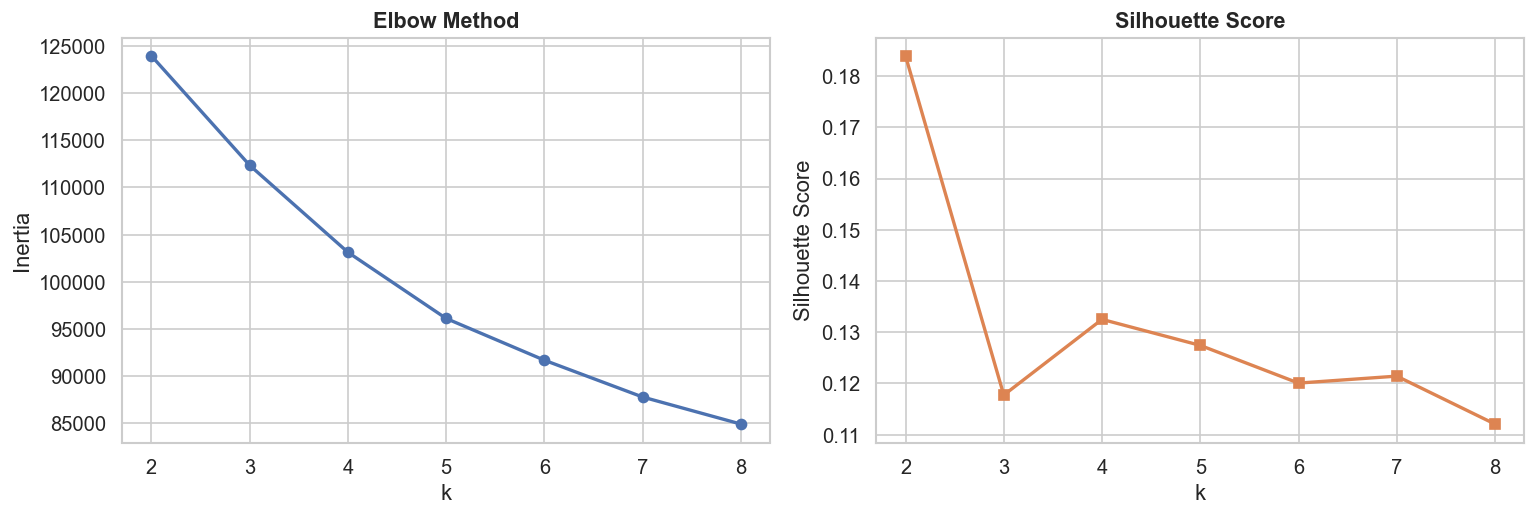

Best silhouette at k=2 (0.184)


In [59]:
k_range = range(2, 9)
inertias, silhouettes = [], []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(cluster_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(cluster_scaled, labels, sample_size=3000, random_state=SEED))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(list(k_range), inertias, marker="o", lw=2, color="#4C72B0")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia"); axes[0].set_title("Elbow Method"); axes[0].set_xticks(list(k_range))
axes[1].plot(list(k_range), silhouettes, marker="s", lw=2, color="#DD8452")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette Score"); axes[1].set_title("Silhouette Score"); axes[1].set_xticks(list(k_range))
plt.tight_layout(); plt.show()
print(f"Best silhouette at k={list(k_range)[np.argmax(silhouettes)]} ({max(silhouettes):.3f})")


> Silhouette peaks at k=2, but two clusters just splits "high spenders vs low spenders" which isn't much to work with. The elbow flattens around k=4, so we go with that for more actionable segments.


### 3.3 Fit Final Clusters

In [60]:
N_CLUSTERS = 4
km_final = KMeans(n_clusters=N_CLUSTERS, random_state=SEED, n_init=20)
raw["Cluster"] = km_final.fit_predict(cluster_scaled)
print("Cluster sizes:")
print(raw["Cluster"].value_counts().sort_index().to_string())


Cluster sizes:
Cluster
0    3375
1    4327
2    1041
3    1384


### 3.4 Churn Rate per Cluster

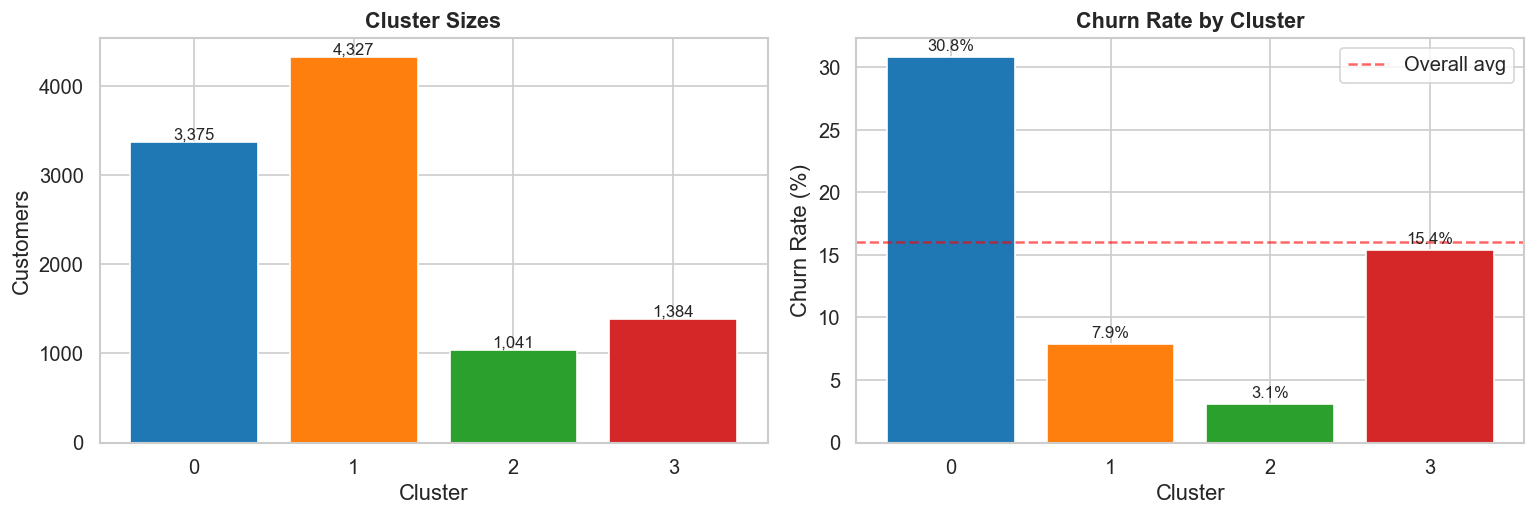

In [61]:
churn_by_cluster = (
    raw.groupby("Cluster")
    .agg(n_customers=("Attrition_Flag", "count"),
         n_churned=("Attrition_Flag", lambda x: (x == "Attrited Customer").sum()))
    .assign(churn_rate=lambda d: d["n_churned"] / d["n_customers"] * 100)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
cluster_colors = [CLUSTER_CMAP(i) for i in range(N_CLUSTERS)]

ax = axes[0]
bars = ax.bar(churn_by_cluster.index.astype(str), churn_by_cluster["n_customers"],
              color=cluster_colors, edgecolor="white")
for bar, val in zip(bars, churn_by_cluster["n_customers"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30, f"{val:,}", ha="center", fontsize=10)
ax.set_xlabel("Cluster"); ax.set_ylabel("Customers"); ax.set_title("Cluster Sizes")

ax = axes[1]
bars = ax.bar(churn_by_cluster.index.astype(str), churn_by_cluster["churn_rate"],
              color=cluster_colors, edgecolor="white")
for bar, val in zip(bars, churn_by_cluster["churn_rate"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f"{val:.1f}%", ha="center", fontsize=10)
ax.set_xlabel("Cluster"); ax.set_ylabel("Churn Rate (%)")
ax.set_title("Churn Rate by Cluster")
ax.axhline(y=raw["Attrition_Flag"].eq("Attrited Customer").mean()*100,
           color="red", ls="--", alpha=0.6, label="Overall avg")
ax.legend()
plt.tight_layout(); plt.show()


### 3.5 Cluster Profiles

In [62]:
profile_cols = ["Customer_Age", "Credit_Limit", "Total_Trans_Ct", "Total_Trans_Amt",
    "Total_Revolving_Bal", "Avg_Utilization_Ratio", "Months_Inactive_12_mon",
    "Total_Relationship_Count", "Total_Ct_Chng_Q4_Q1"]
cluster_profiles = raw.groupby("Cluster")[profile_cols].mean().round(1)
cluster_profiles["Churn Rate (%)"] = churn_by_cluster["churn_rate"].round(1)
cluster_profiles["Size"] = churn_by_cluster["n_customers"]
cluster_profiles.T.style.background_gradient(cmap="YlOrRd", axis=1).set_caption("Cluster Profiles (feature means)")


Cluster,0,1,2,3
Customer_Age,46.700000,46.300000,45.300000,46.400000
Credit_Limit,5981.100000,3910.000000,13122.900000,26481.100000
Total_Trans_Ct,57.700000,62.500000,104.700000,59.700000
Total_Trans_Amt,3267.400000,3510.500000,12821.100000,3638.600000
Total_Revolving_Bal,403.500000,1683.900000,1393.700000,1211.700000
Avg_Utilization_Ratio,0.100000,0.500000,0.200000,0.100000
Months_Inactive_12_mon,2.500000,2.300000,2.200000,2.300000
Total_Relationship_Count,3.900000,4.100000,2.200000,4.000000
Total_Ct_Chng_Q4_Q1,0.600000,0.800000,0.700000,0.700000
Churn Rate (%),30.800000,7.900000,3.100000,15.400000


> The highest-churn cluster stands out: lowest transaction count, lowest revolving balance, highest inactivity. That's the at-risk group. The lowest-churn cluster is the opposite: high activity, high utilization, lots of products. A retention team would treat these very differently.


### 3.6 Cluster Feature Distributions

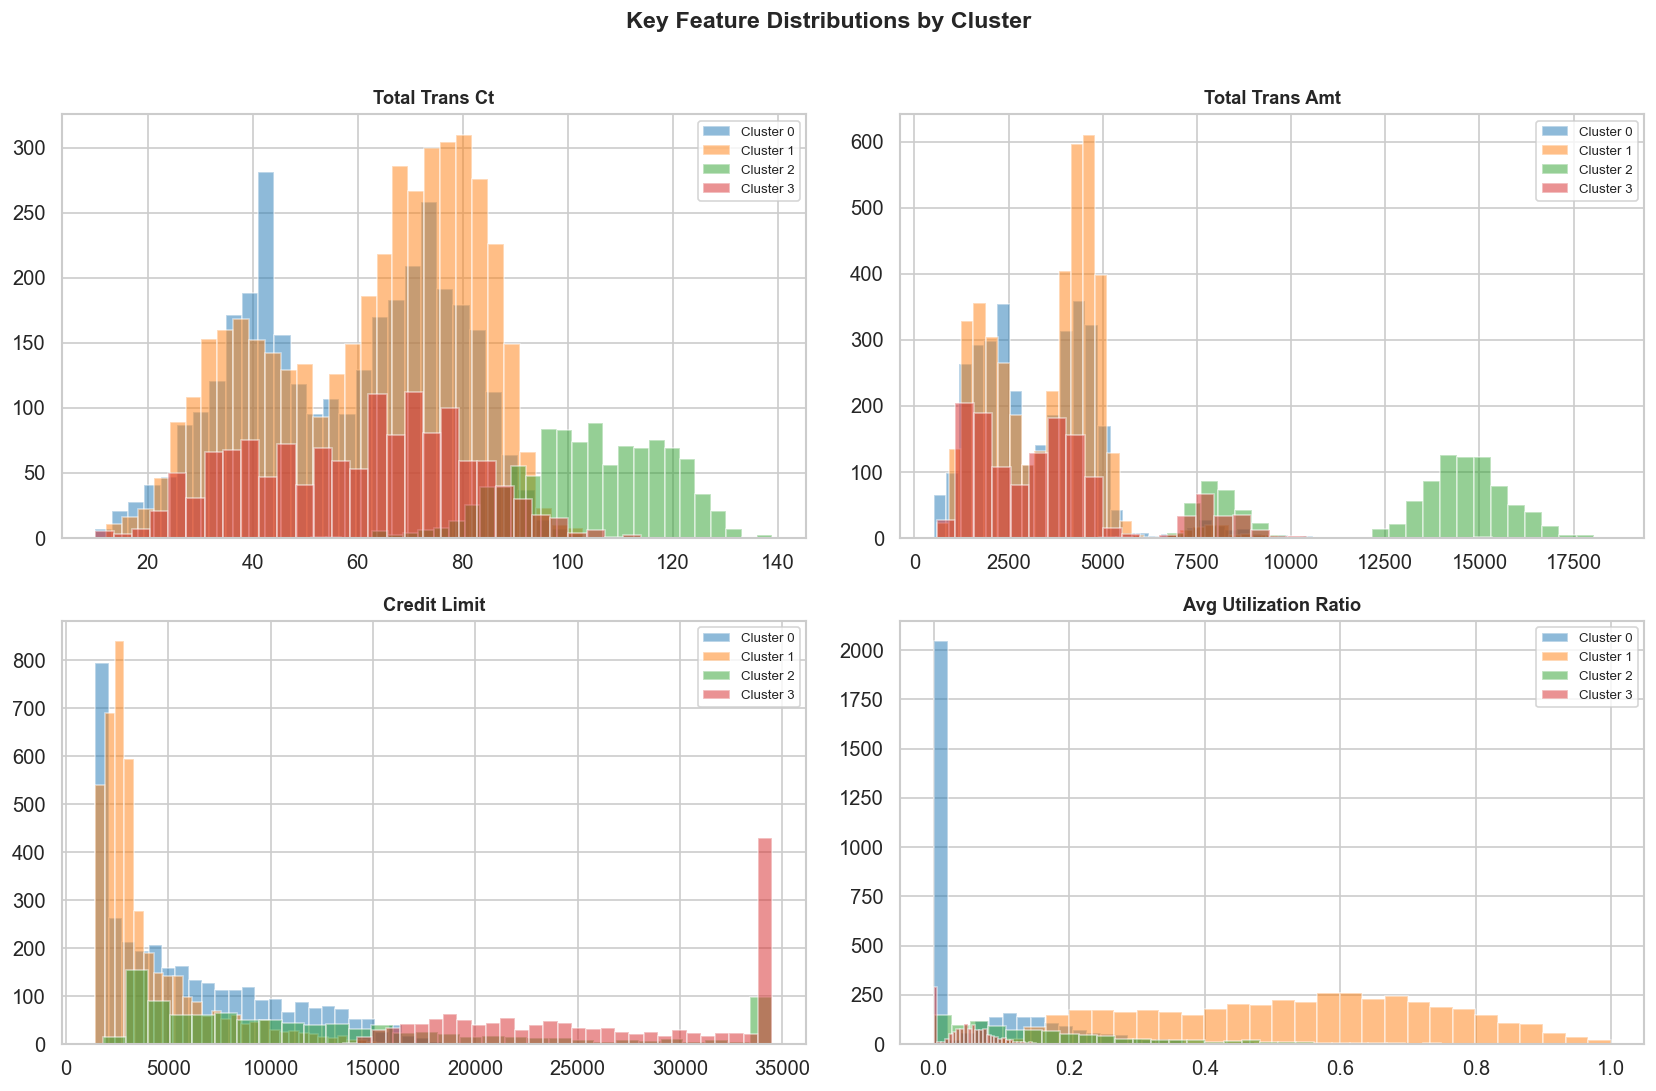

In [63]:
key_features = ["Total_Trans_Ct", "Total_Trans_Amt", "Credit_Limit", "Avg_Utilization_Ratio"]
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col in zip(axes.ravel(), key_features):
    for cid in range(N_CLUSTERS):
        ax.hist(raw.loc[raw["Cluster"]==cid, col], bins=30, alpha=0.5,
                label=f"Cluster {cid}", color=CLUSTER_CMAP(cid), edgecolor="white")
    ax.set_title(col.replace("_", " "), fontsize=11); ax.legend(fontsize=8)
fig.suptitle("Key Feature Distributions by Cluster", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()


## 4. Dimensionality Reduction for Visualization

With 14 numeric features it's hard to see how customers spread out. PCA and t-SNE project everything down to 2D so we can look at the structure directly. PCA keeps the global layout intact (good for seeing overall separation), t-SNE highlights local neighborhoods (good for spotting tight groups).


### 4.1 PCA Projection (2D)

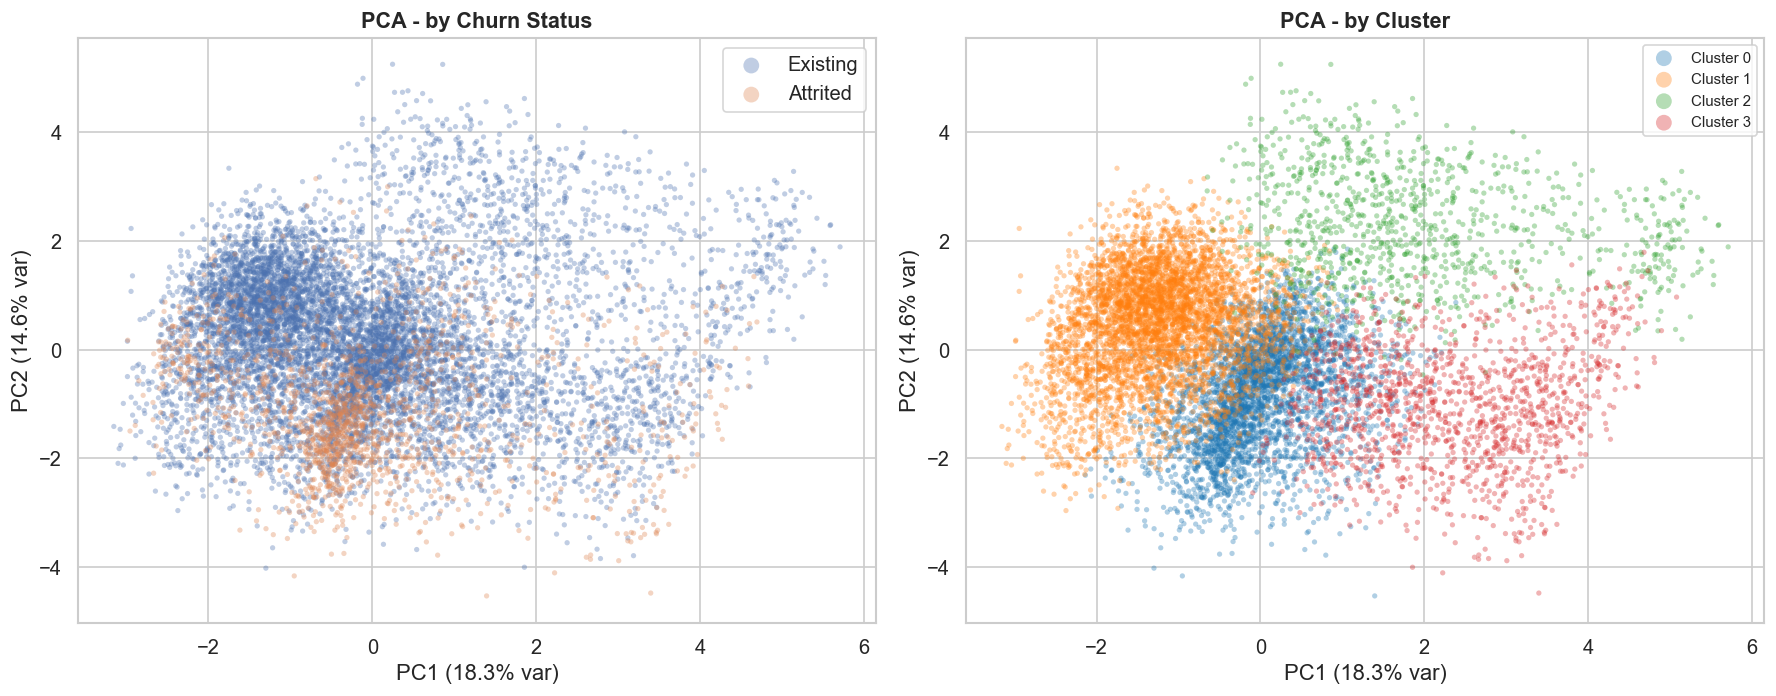

In [64]:
pca_2d = PCA(n_components=2, random_state=SEED)
pca_coords = pca_2d.fit_transform(cluster_scaled)
explained = pca_2d.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
for label, color in STATUS_COLORS.items():
    m = status == label
    ax.scatter(pca_coords[m, 0], pca_coords[m, 1], c=color, label=label, alpha=0.35, s=10, edgecolors="none")
ax.set_xlabel(f"PC1 ({explained[0]:.1%} var)"); ax.set_ylabel(f"PC2 ({explained[1]:.1%} var)")
ax.set_title("PCA - by Churn Status"); ax.legend(markerscale=3)

ax = axes[1]
for cid in range(N_CLUSTERS):
    m = raw["Cluster"].values == cid
    ax.scatter(pca_coords[m, 0], pca_coords[m, 1], c=[CLUSTER_CMAP(cid)],
               label=f"Cluster {cid}", alpha=0.35, s=10, edgecolors="none")
ax.set_xlabel(f"PC1 ({explained[0]:.1%} var)"); ax.set_ylabel(f"PC2 ({explained[1]:.1%} var)")
ax.set_title("PCA - by Cluster"); ax.legend(markerscale=3, fontsize=9)

plt.tight_layout(); plt.show()


> The left panel shows churners concentrated in the lower-left region of the PCA space. Comparing with the right panel, that area maps to the high-churn cluster from our K-Means analysis. The overlap isn't perfect though (some churners are scattered throughout), which is why we need a supervised model and not just clustering alone.


### 4.2 t-SNE Projection (2D)

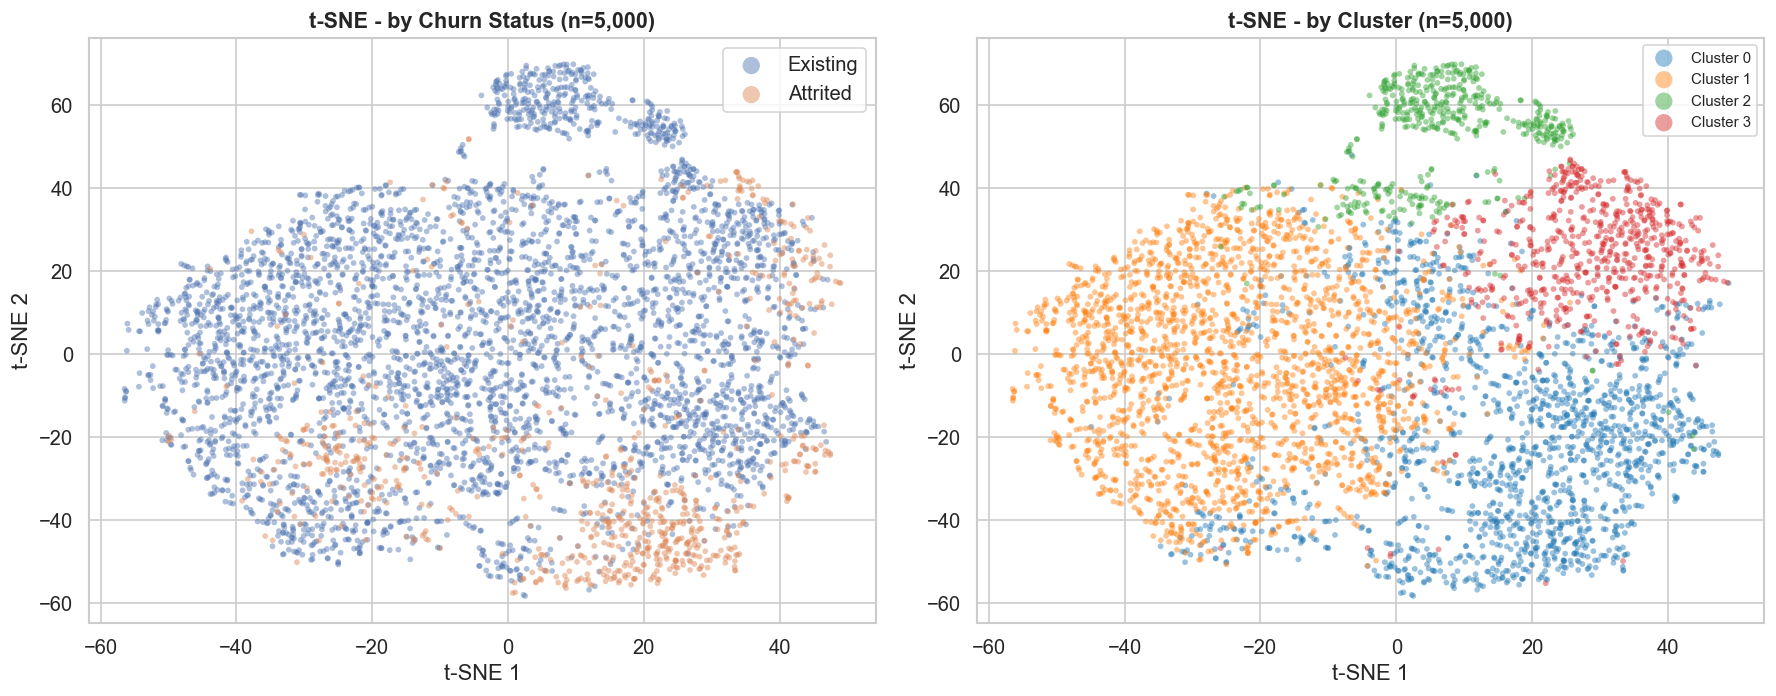

In [65]:
TSNE_SAMPLE = min(5000, len(cluster_scaled))
rng = np.random.RandomState(SEED)
sample_idx = rng.choice(len(cluster_scaled), size=TSNE_SAMPLE, replace=False)

tsne = TSNE(n_components=2, perplexity=40, learning_rate="auto",
            init="pca", random_state=SEED, max_iter=1000)
tsne_coords = tsne.fit_transform(cluster_scaled[sample_idx])
sample_status = status.iloc[sample_idx]
sample_clusters = raw["Cluster"].iloc[sample_idx]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
for label, color in STATUS_COLORS.items():
    m = sample_status == label
    ax.scatter(tsne_coords[m, 0], tsne_coords[m, 1], c=color, label=label, alpha=0.45, s=12, edgecolors="none")
ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
ax.set_title(f"t-SNE - by Churn Status (n={TSNE_SAMPLE:,})"); ax.legend(markerscale=3)

ax = axes[1]
for cid in range(N_CLUSTERS):
    m = sample_clusters == cid
    ax.scatter(tsne_coords[m, 0], tsne_coords[m, 1], c=[CLUSTER_CMAP(cid)],
               label=f"Cluster {cid}", alpha=0.45, s=12, edgecolors="none")
ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
ax.set_title(f"t-SNE - by Cluster (n={TSNE_SAMPLE:,})"); ax.legend(markerscale=3, fontsize=9)

plt.tight_layout(); plt.show()


> t-SNE pulls apart local structure more aggressively. Churners form distinct pockets rather than being evenly mixed in with the existing customers. Cross-referencing with the right panel confirms they concentrate in specific cluster regions. Good sanity check that clustering and supervised targets are picking up on the same underlying signal.


### 4.3 PCA Explained Variance

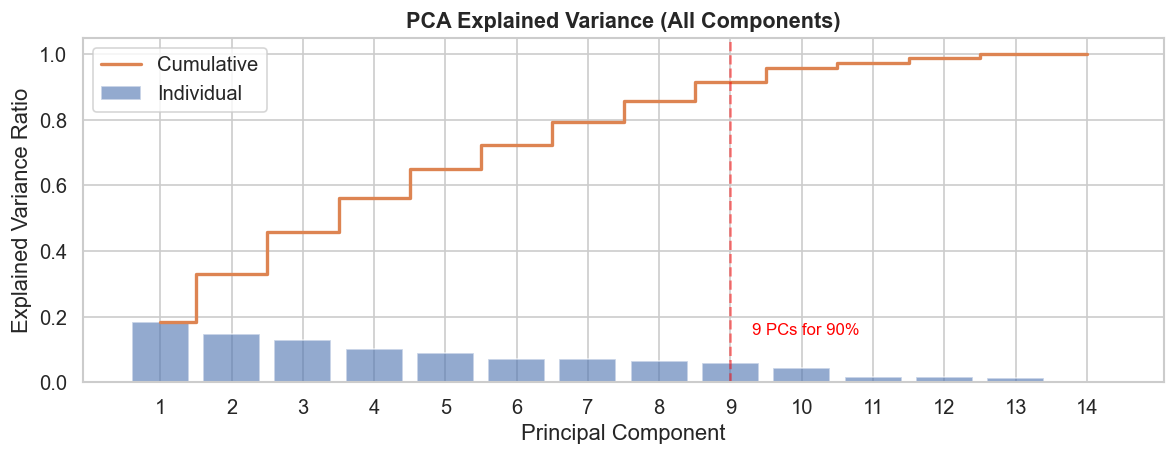

Components for 90% variance: 9
Components for 95% variance: 10


In [66]:
pca_full = PCA(random_state=SEED)
pca_full.fit(cluster_scaled)
evr = pca_full.explained_variance_ratio_
cumvar = np.cumsum(evr)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(1, len(evr)+1), evr, alpha=0.6, color="#4C72B0", edgecolor="white", label="Individual")
ax.step(range(1, len(evr)+1), cumvar, where="mid", color="#DD8452", lw=2, label="Cumulative")
n_90 = np.searchsorted(cumvar, 0.90) + 1
ax.axvline(x=n_90, color="red", ls="--", alpha=0.5)
ax.text(n_90+0.3, max(evr)*0.8, f"{n_90} PCs for 90%", fontsize=10, color="red")
ax.set_xlabel("Principal Component"); ax.set_ylabel("Explained Variance Ratio")
ax.set_title("PCA Explained Variance (All Components)"); ax.legend()
ax.set_xticks(range(1, len(evr)+1))
plt.tight_layout(); plt.show()
print(f"Components for 90% variance: {n_90}")
print(f"Components for 95% variance: {np.searchsorted(cumvar, 0.95)+1}")


> About 9 components capture 90% of the variance. Useful to know, but since our tree-based models handle high-dimensional data natively, we don't use PCA as a preprocessing step in the pipeline. It's here for interpretation only.


## 5. Feature Engineering & Preprocessing

Now we shift from exploration to modelling. We encode the features, split train/test, and build a preprocessing pipeline that handles scaling and encoding automatically. The important design choice: SMOTE goes inside the pipeline so synthetic minority samples only ever touch training folds, never the test set. This prevents data leakage.


### 5.1 Encode & Prepare Features

In [67]:
df = raw.copy()
df["churn"] = (df["Attrition_Flag"] == "Attrited Customer").astype(int)
df.drop(columns=["CLIENTNUM", "Attrition_Flag", "Cluster"], inplace=True)

cat_cols = ["Gender", "Education_Level", "Marital_Status", "Income_Category", "Card_Category"]
num_cols = [c for c in df.columns if c not in cat_cols + ["churn"]]

features = df.drop(columns=["churn"])
target = df["churn"]

print(f"Features: {features.shape[1]}  |  Numeric: {len(num_cols)}  |  Categorical: {len(cat_cols)}")
print(f"Target split:\n{target.value_counts().to_string()}")


Features: 19  |  Numeric: 14  |  Categorical: 5
Target split:
churn
0    8500
1    1627


### 5.2 Stratified Train / Test Split

In [68]:
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.20, stratify=target, random_state=SEED)
print(f"Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}")
print(f"Train churn rate: {y_train.mean():.2%}  |  Test churn rate: {y_test.mean():.2%}")


Train: 8,101  |  Test: 2,026
Train churn rate: 16.07%  |  Test churn rate: 16.04%


### 5.3 Preprocessing Pipeline

The `ColumnTransformer` applies `StandardScaler` to numeric features and `OrdinalEncoder` to categoricals. We use ordinal encoding instead of one-hot because all our final models are tree-based, and trees split on individual thresholds rather than needing a binary indicator per category. Keeps the feature space compact.

SMOTE is baked into the `imblearn` pipeline so it only touches training folds. No leakage.


In [69]:
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_cols),
    ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), cat_cols),
], remainder="drop")
X_train_proc = preprocessor.fit_transform(X_train)
print(f"Transformed shape: {X_train_proc.shape}")


Transformed shape: (8101, 19)


## 6. Model Training & Selection

We compare five classifiers. Each one is wrapped in an `imblearn` pipeline that applies preprocessing and SMOTE before fitting, so every cross-validation fold gets a clean, uncontaminated training set.


| Model | Why it's here |
|-------|---------------|
| Logistic Regression | Simple baseline, tells us how far a linear model can go |
| Random Forest | Reliable ensemble, good at mixed feature types |
| Gradient Boosting (sklearn) | Sequential learner with interpretable importances |
| XGBoost | Industry workhorse for tabular data, built-in regularization |
| LightGBM | Fast, handles categoricals natively, strong on tabular benchmarks |


In [70]:
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=SEED),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=12, min_samples_leaf=5, random_state=SEED, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1, random_state=SEED),
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        use_label_encoder=False, eval_metric="logloss",
        random_state=SEED, n_jobs=-1, verbosity=0),
    "LightGBM": LGBMClassifier(
        n_estimators=300, max_depth=8, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        random_state=SEED, n_jobs=-1, verbose=-1),
}
pipes = {}
for name, clf in classifiers.items():
    pipes[name] = ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=SEED)),
        ("classifier", clf),
    ])
print(f"{len(pipes)} pipelines ready")


5 pipelines ready


### 6.1 Stratified 5-Fold Cross-Validation

In [71]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
scoring = ["f1", "roc_auc", "precision", "recall"]
cv_scores = {}
for name, pipe in pipes.items():
    print(f"  {name}...", end=" ", flush=True)
    result = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring,
                            return_train_score=False, n_jobs=-1)
    cv_scores[name] = result
    print(f"F1={result['test_f1'].mean():.3f} +/- {result['test_f1'].std():.3f}  "
          f"AUC={result['test_roc_auc'].mean():.3f}")
print("\nDone")


  Logistic Regression... F1=0.648 +/- 0.017  AUC=0.925
  Random Forest... F1=0.863 +/- 0.009  AUC=0.986
  Gradient Boosting... F1=0.908 +/- 0.012  AUC=0.992
  XGBoost... F1=0.912 +/- 0.013  AUC=0.993
  LightGBM... F1=0.917 +/- 0.012  AUC=0.993

Done


In [72]:
rows = []
for name, result in cv_scores.items():
    rows.append({
        "Model": name,
        "F1 (mean +/- std)": f"{result['test_f1'].mean():.3f} +/- {result['test_f1'].std():.3f}",
        "ROC-AUC (mean +/- std)": f"{result['test_roc_auc'].mean():.3f} +/- {result['test_roc_auc'].std():.3f}",
        "Precision": f"{result['test_precision'].mean():.3f}",
        "Recall": f"{result['test_recall'].mean():.3f}",
    })
cv_table = pd.DataFrame(rows).set_index("Model")
cv_table.style.set_caption("5-Fold CV Results (Training Set)")


,F1 (mean +/- std),ROC-AUC (mean +/- std),Precision,Recall
Model,,,,
Logistic Regression,0.648 +/- 0.017,0.925 +/- 0.007,0.527,0.841
Random Forest,0.863 +/- 0.009,0.986 +/- 0.003,0.846,0.882
Gradient Boosting,0.908 +/- 0.012,0.992 +/- 0.001,0.912,0.905
XGBoost,0.912 +/- 0.013,0.993 +/- 0.002,0.926,0.899
LightGBM,0.917 +/- 0.012,0.993 +/- 0.001,0.927,0.907


### 6.2 Cross-Validation Visualization

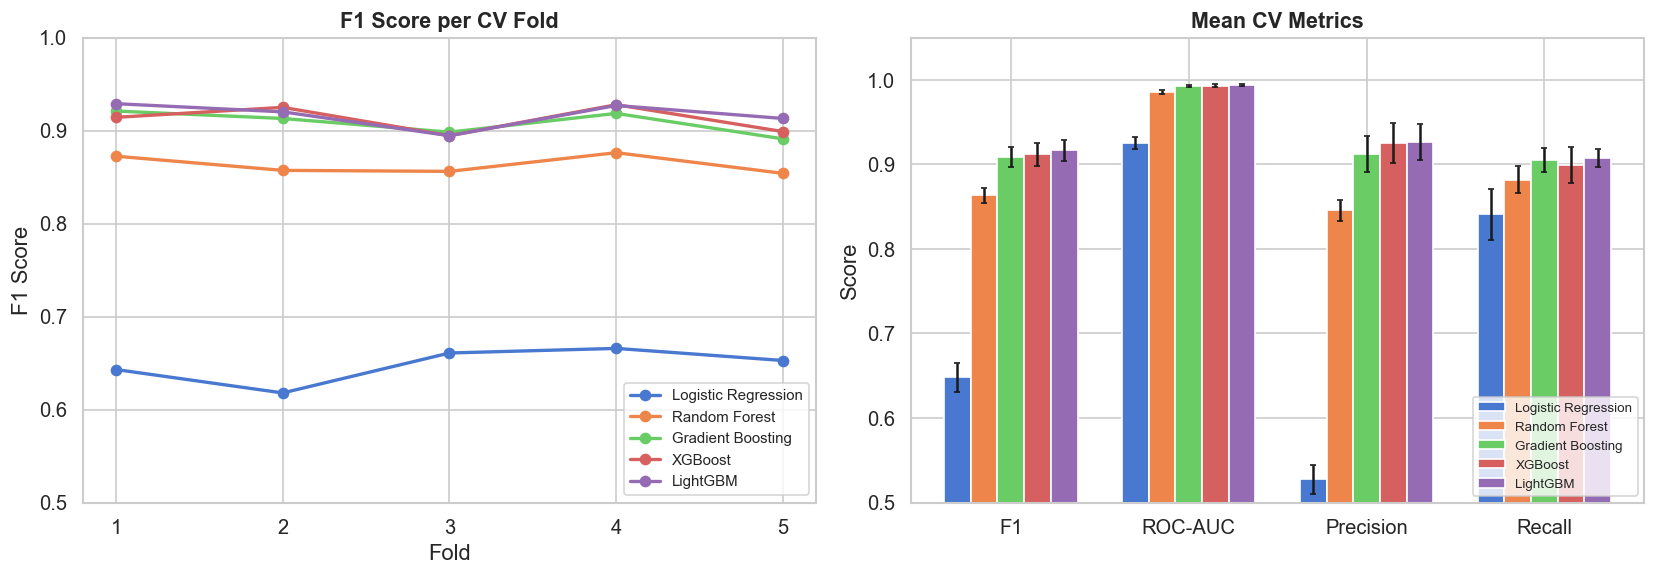

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for name, result in cv_scores.items():
    ax.plot(range(1,6), result["test_f1"], marker="o", label=name, lw=2)
ax.set_xlabel("Fold"); ax.set_ylabel("F1 Score"); ax.set_title("F1 Score per CV Fold")
ax.set_xticks(range(1,6)); ax.legend(fontsize=9, loc="lower right"); ax.set_ylim(0.5, 1.0)

ax = axes[1]
metric_labels = ["F1", "ROC-AUC", "Precision", "Recall"]
metric_keys = ["test_f1", "test_roc_auc", "test_precision", "test_recall"]
x = np.arange(len(metric_labels)); w = 0.15
offsets = np.linspace(-w*2, w*2, len(cv_scores))
for i, (name, result) in enumerate(cv_scores.items()):
    means = [result[k].mean() for k in metric_keys]
    stds = [result[k].std() for k in metric_keys]
    ax.bar(x+offsets[i], means, w, label=name, yerr=stds, capsize=2, edgecolor="white")
ax.set_xticks(x); ax.set_xticklabels(metric_labels)
ax.set_ylabel("Score"); ax.set_title("Mean CV Metrics")
ax.legend(fontsize=8, loc="lower right"); ax.set_ylim(0.5, 1.05)

plt.tight_layout(); plt.show()


## 7. Evaluation on Held-Out Test Set

Cross-validation gives us confidence in the models, but the real test is performance on data they've never seen. We refit each pipeline on the full training set and score the 20% holdout.


### 7.1 Fit & Predict

In [74]:
preds, probas = {}, {}
for name, pipe in pipes.items():
    pipe.fit(X_train, y_train)
    preds[name] = pipe.predict(X_test)
    if hasattr(pipe.named_steps["classifier"], "predict_proba"):
        probas[name] = pipe.predict_proba(X_test)[:, 1]
print("All models scored on test set")


All models scored on test set


### 7.2 Test Set Metrics

In [75]:
test_rows = []
for name, y_pred in preds.items():
    proba = probas.get(name)
    report = classification_report(y_test, y_pred, output_dict=True)
    test_rows.append({
        "Model": name,
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, proba) if proba is not None else np.nan,
        "Precision": report["1"]["precision"],
        "Recall": report["1"]["recall"],
    })
test_table = pd.DataFrame(test_rows).set_index("Model").round(4)
test_table.sort_values("F1", ascending=False).style.background_gradient(
    cmap="YlGn", subset=["F1", "ROC-AUC"]).set_caption("Test Set Performance")


,F1,ROC-AUC,Precision,Recall
Model,,,,
LightGBM,0.911900,0.992900,0.932500,0.892300
XGBoost,0.908500,0.992400,0.932000,0.886200
Gradient Boosting,0.897000,0.991200,0.924800,0.870800
Random Forest,0.834800,0.982000,0.815200,0.855400
Logistic Regression,0.637000,0.915700,0.532000,0.793800


### 7.3 Classification Report (Best Model)

In [76]:
best_name = test_table["F1"].idxmax()
best_pred = preds[best_name]
print(f"Best model by F1: {best_name}\n")
print(classification_report(y_test, best_pred, target_names=["Existing", "Attrited"]))


Best model by F1: LightGBM

              precision    recall  f1-score   support

    Existing       0.98      0.99      0.98      1701
    Attrited       0.93      0.89      0.91       325

    accuracy                           0.97      2026
   macro avg       0.96      0.94      0.95      2026
weighted avg       0.97      0.97      0.97      2026



### 7.4 Confusion Matrices

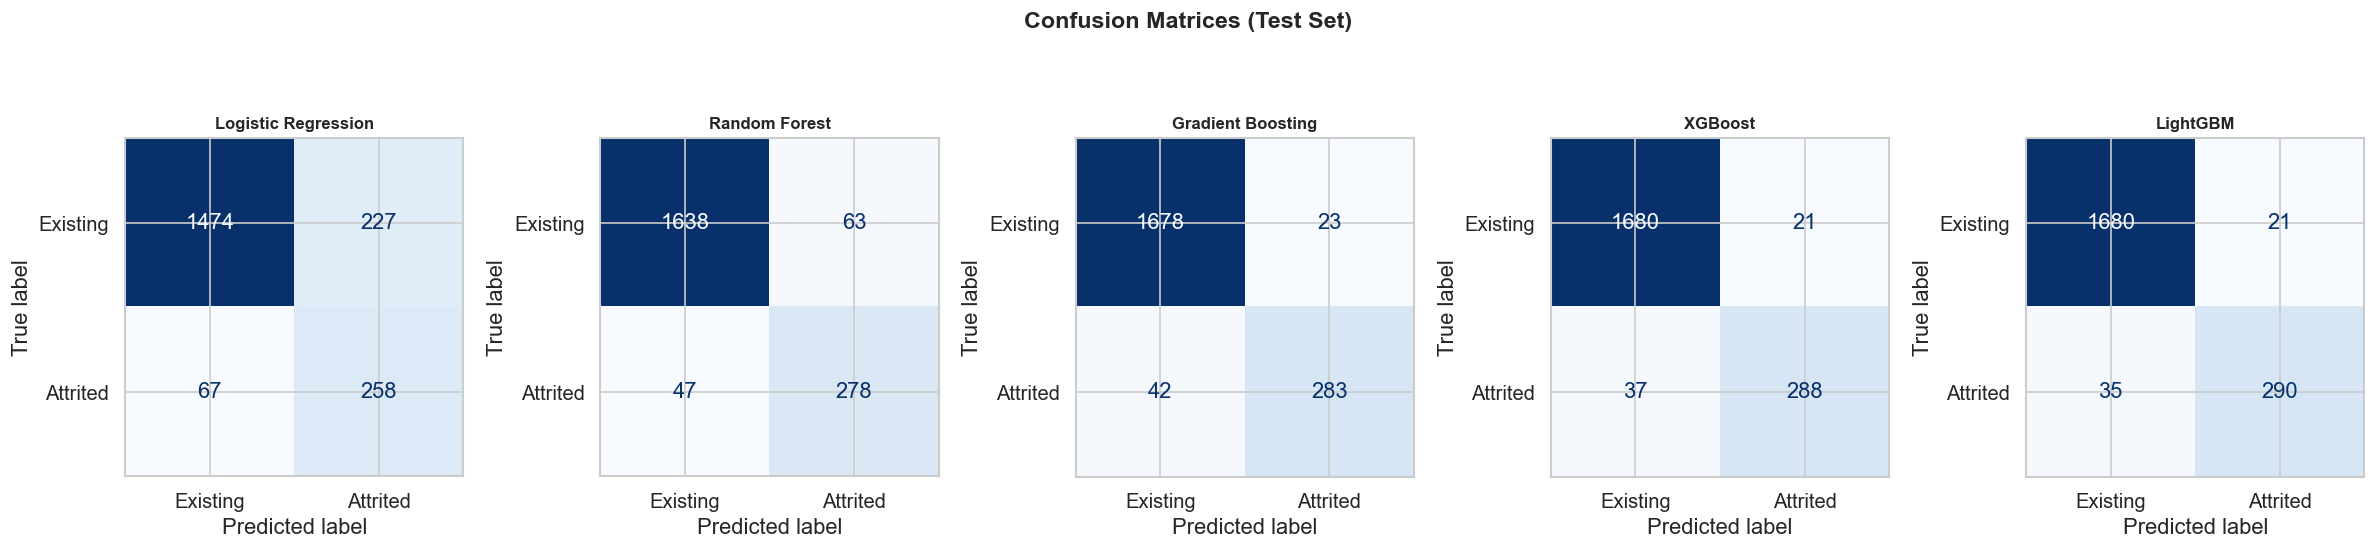

In [77]:
n_models = len(pipes)
fig, axes = plt.subplots(1, n_models, figsize=(4 * n_models, 4.5))

for ax, (name, y_pred) in zip(axes, preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["Existing", "Attrited"]).plot(
        ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(name, fontsize=10)

fig.suptitle("Confusion Matrices (Test Set)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()


### 7.5 ROC Curves

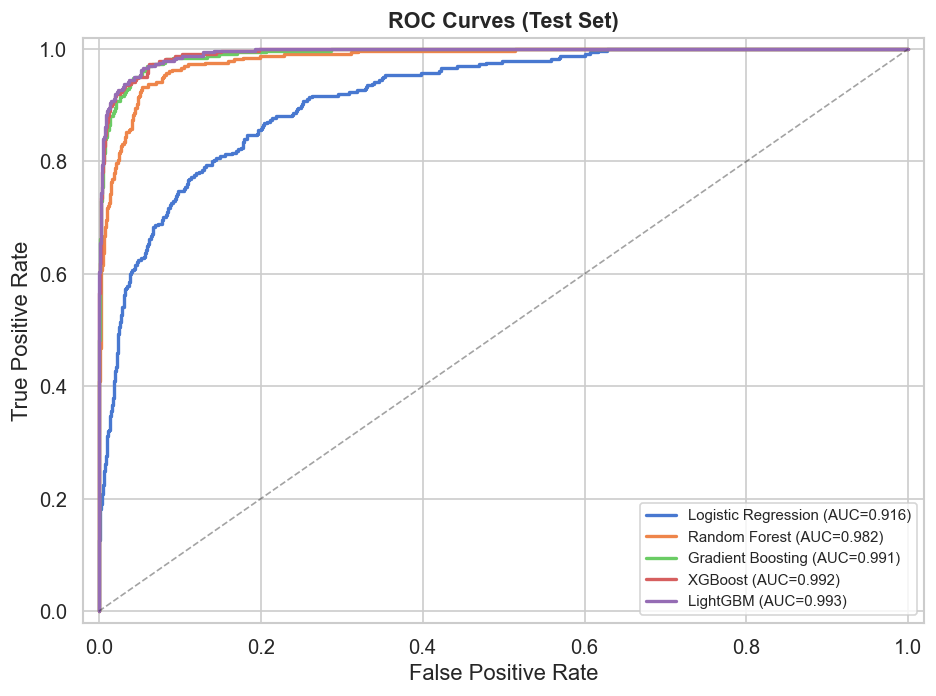

In [78]:
fig, ax = plt.subplots(figsize=(8, 6))
for name, proba in probas.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, lw=2, label=f"{name} (AUC={roc_auc_score(y_test, proba):.3f})")
ax.plot([0,1], [0,1], "k--", alpha=0.4, lw=1)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves (Test Set)"); ax.legend(loc="lower right", fontsize=9)
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
plt.tight_layout(); plt.show()


### 7.6 Precision-Recall Curves

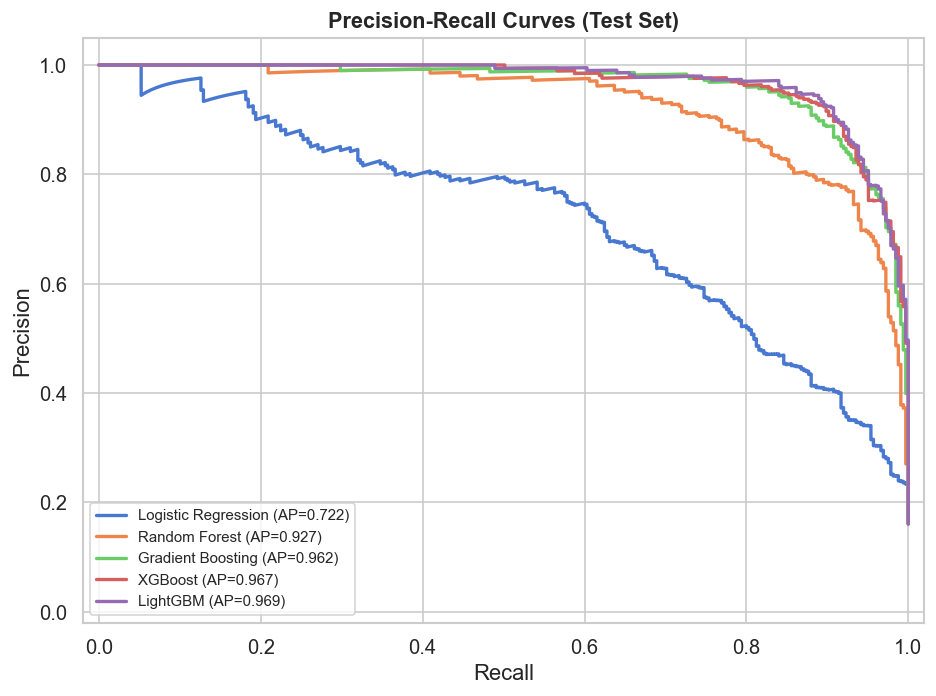

In [79]:
fig, ax = plt.subplots(figsize=(8, 6))
for name, proba in probas.items():
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ax.plot(rec, prec, lw=2, label=f"{name} (AP={average_precision_score(y_test, proba):.3f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves (Test Set)"); ax.legend(loc="lower left", fontsize=9)
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.05)
plt.tight_layout(); plt.show()


### 7.7 Feature Importance (Random Forest)

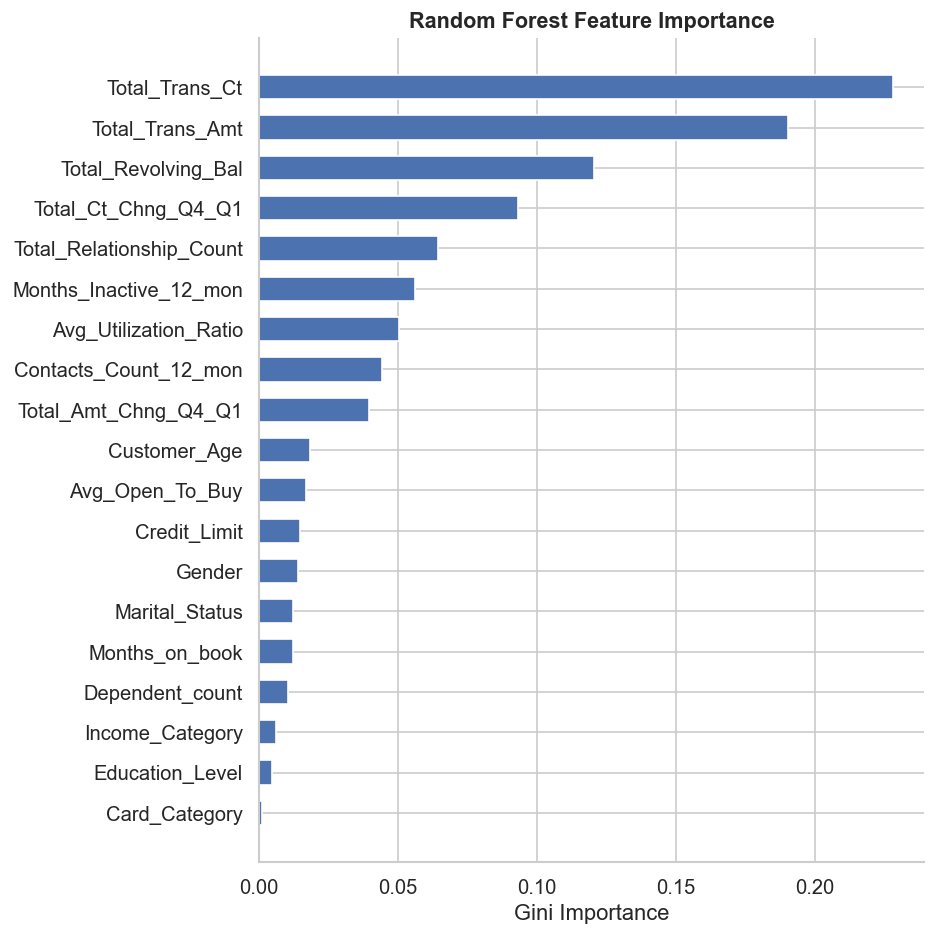

Top 5:
  Total_Trans_Ct                  0.2281
  Total_Trans_Amt                 0.1904
  Total_Revolving_Bal             0.1207
  Total_Ct_Chng_Q4_Q1             0.0932
  Total_Relationship_Count        0.0646


In [80]:
rf_model = pipes["Random Forest"].named_steps["classifier"]
all_feature_names = num_cols + cat_cols
rf_imp = rf_model.feature_importances_
rf_order = np.argsort(rf_imp)

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(np.array(all_feature_names)[rf_order], rf_imp[rf_order],
        color="#4C72B0", edgecolor="white", height=0.6)
ax.set_xlabel("Gini Importance"); ax.set_title("Random Forest Feature Importance", fontweight="bold")
for s in ["top","right"]: ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()
print("Top 5:")
for i in rf_order[-5:][::-1]: print(f"  {all_feature_names[i]:30s}  {rf_imp[i]:.4f}")


### 7.8 Feature Importance (XGBoost)

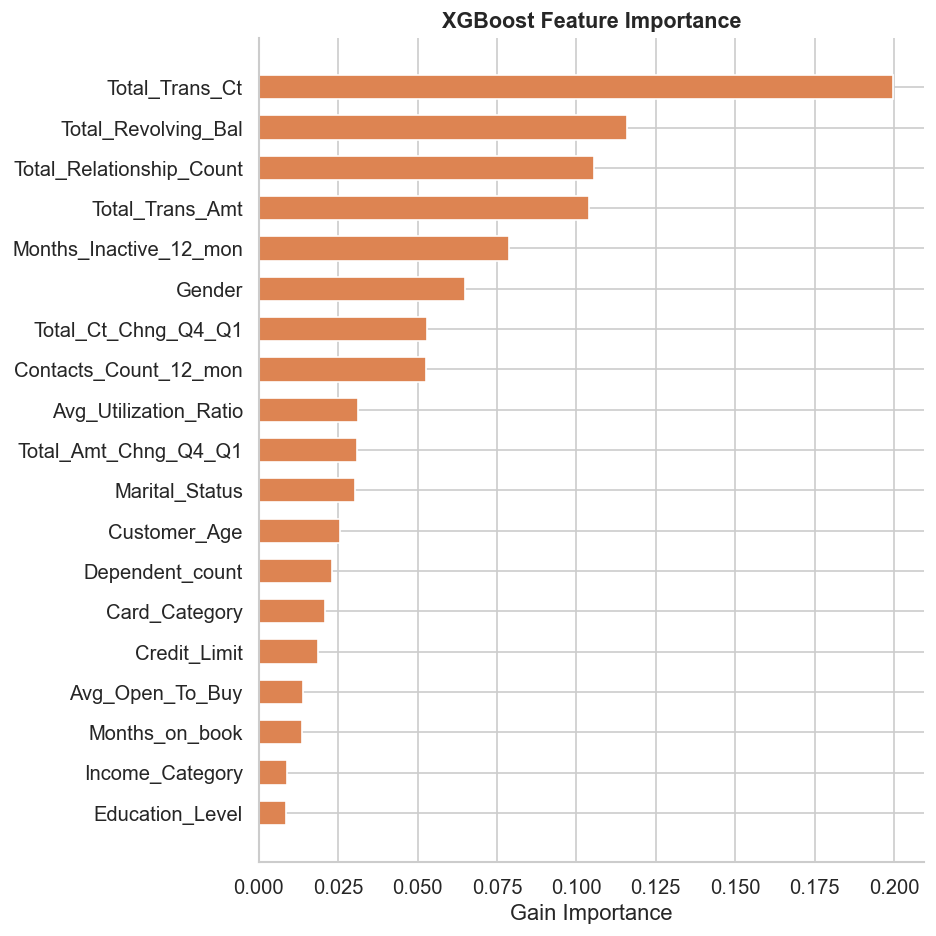

In [81]:
xgb_imp = pipes["XGBoost"].named_steps["classifier"].feature_importances_
xgb_order = np.argsort(xgb_imp)
fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(np.array(all_feature_names)[xgb_order], xgb_imp[xgb_order],
        color="#DD8452", edgecolor="white", height=0.6)
ax.set_xlabel("Gain Importance"); ax.set_title("XGBoost Feature Importance", fontweight="bold")
for s in ["top","right"]: ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()


### 7.9 Feature Importance (LightGBM)

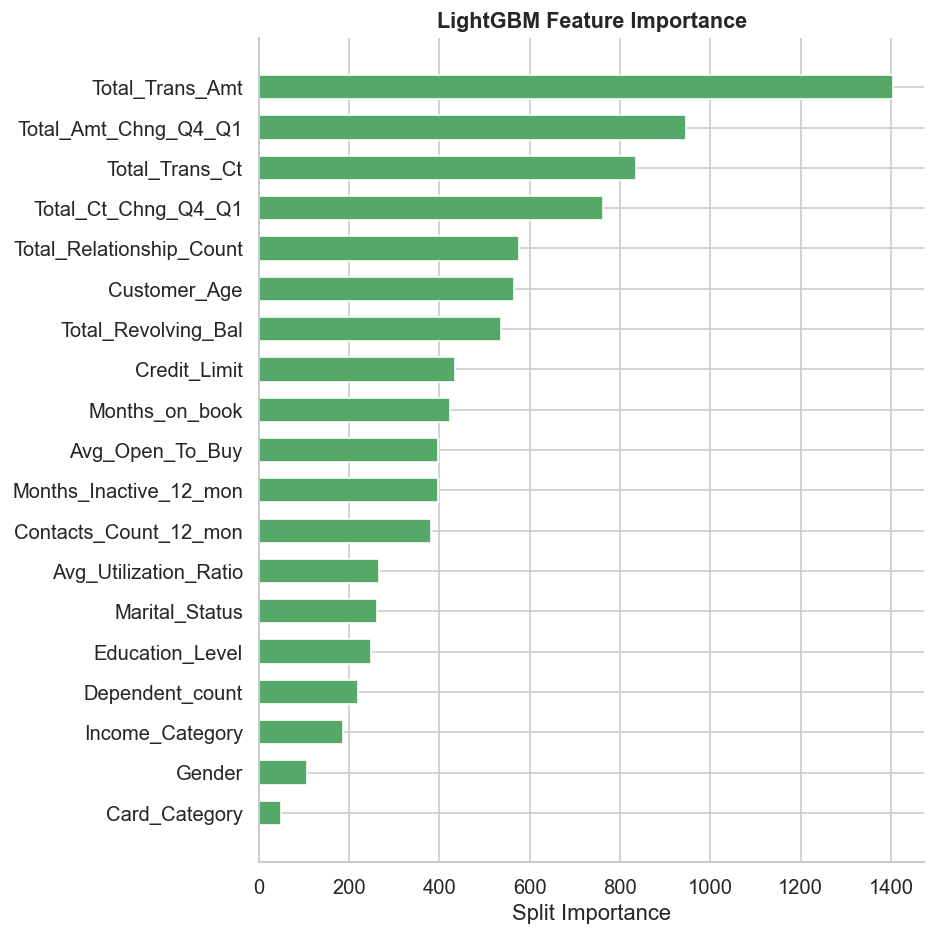

In [82]:
lgbm_imp = pipes["LightGBM"].named_steps["classifier"].feature_importances_
lgbm_order = np.argsort(lgbm_imp)
fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(np.array(all_feature_names)[lgbm_order], lgbm_imp[lgbm_order],
        color="#55A868", edgecolor="white", height=0.6)
ax.set_xlabel("Split Importance"); ax.set_title("LightGBM Feature Importance", fontweight="bold")
for s in ["top","right"]: ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()


## 8. Threshold Tuning & Retention Strategy

A model that says "this customer will churn" is only half the story. The other half is: at what confidence level do we act, and how do we prioritize outreach? This section optimizes the decision threshold, then builds a targeting framework a bank could actually use.


### 8.1 Threshold Analysis

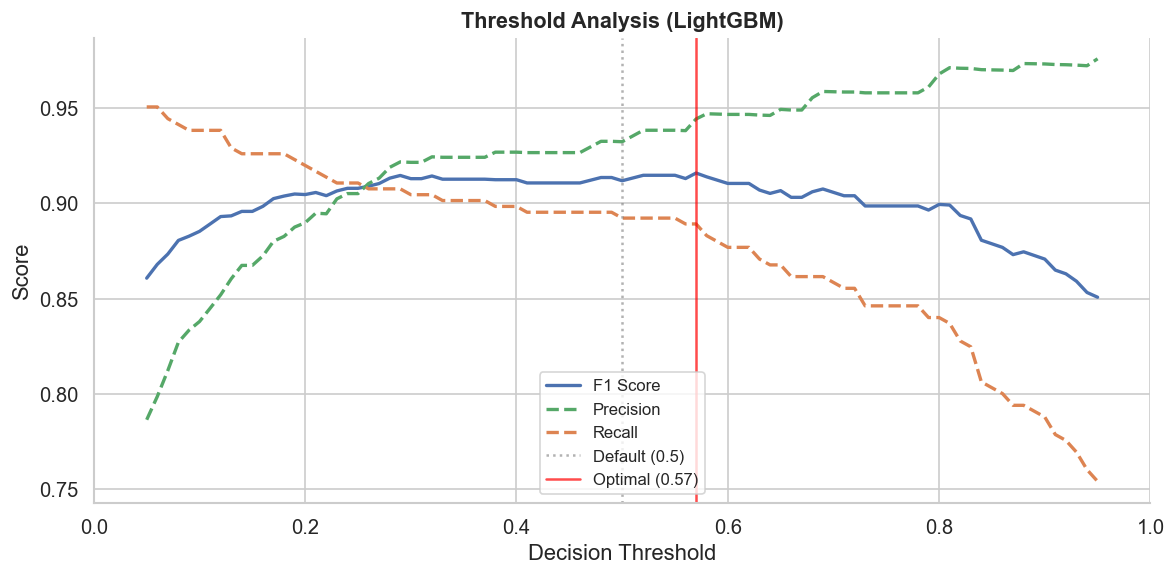

Optimal threshold: 0.57
  F1 at optimal:   0.916
  Precision:        0.944
  Recall:           0.889


In [83]:
best_proba = probas[best_name]
thresholds = np.arange(0.05, 0.96, 0.01)

f1s, precisions, recalls = [], [], []
for t in thresholds:
    y_t = (best_proba >= t).astype(int)
    tp = ((y_t == 1) & (y_test == 1)).sum()
    fp = ((y_t == 1) & (y_test == 0)).sum()
    fn = ((y_t == 0) & (y_test == 1)).sum()
    p = tp / (tp + fp) if (tp + fp) > 0 else 0
    r = tp / (tp + fn) if (tp + fn) > 0 else 0
    f = 2 * p * r / (p + r) if (p + r) > 0 else 0
    precisions.append(p); recalls.append(r); f1s.append(f)

optimal_idx = np.argmax(f1s)
optimal_threshold = thresholds[optimal_idx]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, f1s, label="F1 Score", lw=2, color="#4C72B0")
ax.plot(thresholds, precisions, label="Precision", lw=2, color="#55A868", ls="--")
ax.plot(thresholds, recalls, label="Recall", lw=2, color="#DD8452", ls="--")
ax.axvline(x=0.5, color="grey", ls=":", alpha=0.6, label="Default (0.5)")
ax.axvline(x=optimal_threshold, color="red", ls="-", alpha=0.7, label=f"Optimal ({optimal_threshold:.2f})")
ax.set_xlabel("Decision Threshold"); ax.set_ylabel("Score")
ax.set_title(f"Threshold Analysis ({best_name})", fontweight="bold")
ax.legend(fontsize=10); ax.set_xlim(0, 1)
for s in ["top","right"]: ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

print(f"Optimal threshold: {optimal_threshold:.2f}")
print(f"  F1 at optimal:   {f1s[optimal_idx]:.3f}")
print(f"  Precision:        {precisions[optimal_idx]:.3f}")
print(f"  Recall:           {recalls[optimal_idx]:.3f}")


### 8.2 Cost-Benefit Simulation

In [84]:
# Assumptions (adjust to your bank's reality)
AVG_ANNUAL_REVENUE_PER_CUSTOMER = 500   # $ annual revenue from a credit card customer
COST_OF_RETENTION_OFFER = 50            # $ cost per retention offer (discount, waived fee, etc.)
RETENTION_SUCCESS_RATE = 0.30           # 30% of targeted at-risk customers actually stay

# Compare: no model vs model at default threshold vs model at optimal threshold
n_test = len(y_test)
n_actual_churners = y_test.sum()

scenarios = {}
for label, thresh in [("No Model (do nothing)", None),
                      ("Model @ 0.50 threshold", 0.50),
                      (f"Model @ {optimal_threshold:.2f} threshold", optimal_threshold)]:
    if thresh is None:
        flagged = 0; caught = 0; false_alarms = 0
    else:
        y_t = (best_proba >= thresh).astype(int)
        flagged = y_t.sum()
        caught = ((y_t == 1) & (y_test == 1)).sum()
        false_alarms = ((y_t == 1) & (y_test == 0)).sum()
    
    saved = int(caught * RETENTION_SUCCESS_RATE)
    revenue_saved = saved * AVG_ANNUAL_REVENUE_PER_CUSTOMER
    retention_cost = flagged * COST_OF_RETENTION_OFFER
    net_benefit = revenue_saved - retention_cost
    
    scenarios[label] = {
        "Customers flagged": flagged,
        "True churners caught": caught,
        "False alarms": false_alarms,
        f"Saved ({RETENTION_SUCCESS_RATE:.0%} rate)": saved,
        "Revenue saved ($)": f"${revenue_saved:,.0f}",
        "Retention cost ($)": f"${retention_cost:,.0f}",
        "Net benefit ($)": f"${net_benefit:,.0f}",
    }

scenario_df = pd.DataFrame(scenarios).T
scenario_df.index.name = "Scenario"
scenario_df.style.set_caption("Retention Cost-Benefit Analysis (Test Set)")


,Customers flagged,True churners caught,False alarms,Saved (30% rate),Revenue saved ($),Retention cost ($),Net benefit ($)
Scenario,,,,,,,
No Model (do nothing),0,0,0,0,$0,$0,$0
Model @ 0.50 threshold,311,290,21,87,"$43,500","$15,550","$27,950"
Model @ 0.57 threshold,306,289,17,86,"$43,000","$15,300","$27,700"


> The table above uses placeholder assumptions to illustrate the framework ($500 annual revenue, $50 per offer, 30% save rate). Plug in your own numbers and the structure still holds. The point is that even cheap, imperfect intervention pays for itself when the model is catching the right people.


### 8.3 Who to Target First

In [85]:
# Score the full test set and rank by churn probability
targeting = X_test.copy()
targeting["churn_probability"] = best_proba
targeting["actual_churn"] = y_test.values

# Split into risk tiers
targeting["risk_tier"] = pd.cut(
    targeting["churn_probability"],
    bins=[0, 0.2, 0.5, 0.8, 1.0],
    labels=["Low", "Medium", "High", "Critical"]
)

tier_summary = (
    targeting.groupby("risk_tier", observed=True)
    .agg(
        n_customers=("churn_probability", "count"),
        avg_prob=("churn_probability", "mean"),
        actual_churn_rate=("actual_churn", "mean"),
        avg_trans_ct=("Total_Trans_Ct", "mean"),
        avg_credit_limit=("Credit_Limit", "mean"),
    )
    .round(3)
)
tier_summary["actual_churn_rate"] = (tier_summary["actual_churn_rate"] * 100).round(1).astype(str) + "%"

tier_summary.style.background_gradient(
    cmap="YlOrRd", subset=["avg_prob"]
).set_caption("Risk Tiers: Who to Call First")


,n_customers,avg_prob,actual_churn_rate,avg_trans_ct,avg_credit_limit
risk_tier,,,,,
Low,1690,0.005000,1.5%,69.459000,8966.482000
Medium,25,0.295000,36.0%,41.520000,8851.932000
High,29,0.655000,58.6%,52.000000,7690.400000
Critical,282,0.981000,96.8%,45.184000,8194.940000


> This is a ready-made call list. "Critical" tier customers have the highest churn probability and the profile to match: low transaction counts, low spend, more inactivity. Retention teams start here and work down. The profile columns help reps prepare for the conversation before they even pick up the phone.


## 9. Model Export

In [86]:
best_pipe = pipes[best_name]
export_path = "churn_model.pkl"
joblib.dump(best_pipe, export_path)
file_size_mb = os.path.getsize(export_path) / (1024 * 1024)
print(f"Saved best pipeline ({best_name}) to '{export_path}'")
print(f"File size: {file_size_mb:.1f} MB")
print(f"\nTo load later:")
print(f"  pipe = joblib.load('{export_path}')")
print(f"  predictions = pipe.predict(new_data)")


Saved best pipeline (LightGBM) to 'churn_model.pkl'
File size: 1.2 MB

To load later:
  pipe = joblib.load('churn_model.pkl')
  predictions = pipe.predict(new_data)


## 10. Conclusion

This notebook took a 10k-row credit card dataset and turned it into a deployable churn prediction system.

The single biggest predictor of churn is how much a customer uses their card. Transaction count, transaction amount, and the quarter-over-quarter change in activity all dominate feature importance across every model we tested. Engagement metrics (inactivity, bank contacts, products held) add useful secondary signal. Demographics contribute almost nothing.

Unsupervised clustering backed this up. The highest-churn customer segment is also the one with the lowest transaction activity, lowest utilization, and most inactivity. PCA and t-SNE projections showed these customers concentrating in distinct regions of the feature space, confirming that the supervised and unsupervised analyses are picking up on the same behaviour.

LightGBM came out on top for F1, closely followed by XGBoost and sklearn's Gradient Boosting. All three are strong. Logistic Regression trails meaningfully, telling us there's nonlinear signal in the data.

The threshold analysis in Section 8 turns predictions into something actionable. Rather than committing to a single cutoff, we showed how the catch-rate vs false-alarm tradeoff shifts across thresholds, so the bank can choose the operating point that fits their cost structure. The risk tier table provides a concrete starting point for retention outreach.

For production, next steps would be SHAP values for individual explanations, a monitoring pipeline for feature and prediction drift, and richer temporal features like days-since-last-transaction and rolling averages.


---
*Dataset: [Kaggle - Credit Card Customers](https://www.kaggle.com/datasets/sakshigoyal7/credit-card-customers)*
